In [1]:
import os
import sys

try:
    # 1. Check if we are in Colab
    import google.colab
    print("Colab environment detected. Setting up dependencies...")

    # 2. THE GPU SAFETY CHECK
    import subprocess
    if subprocess.run(['which', 'nvidia-smi']).returncode != 0:
        raise RuntimeError("NO GPU DETECTED! Please go to the top menu -> Runtime -> Change runtime type -> select T4 GPU.")

    # 3. Install system dependencies
    !sudo apt-get update -y
    !sudo apt-get install -y xvfb vulkan-tools glslang-tools vulkan-validationlayers-dev

    # Install the video library (dropping strict versioning for Python 3.12 compatibility)
    !pip install av

    # Dynamically install the exact NVIDIA GL driver
    !sudo apt-get install -y libnvidia-gl-$(nvidia-smi --query-gpu=driver_version --format=csv,noheader | cut -d. -f1)

    print("Cloning repositories...")
    if not os.path.exists('/content/vulky'):
        !git clone https://github.com/rendervous/vulky_project.git /content/vulky
    if not os.path.exists('/content/rdv'):
        !git clone https://github.com/Cdelim/rdv.git /content/rdv

    # 4. Set up the headless Vulkan environment
    os.environ['DISPLAY'] = ':99'
    os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-dir'
    os.makedirs('/tmp/runtime-dir', exist_ok=True)
    os.environ['VK_ICD_FILENAMES'] = '/usr/share/vulkan/icd.d/nvidia_icd.json'

    # Start the invisible monitor
    subprocess.Popen(['Xvfb', ':99', '-screen', '0', '1024x768x24'])

    # 5. Tell Python where to find the source code
    sys.path.append(os.path.abspath('/content/vulky/src'))
    sys.path.append(os.path.abspath('/content/rdv/src'))

except RuntimeError as re:
    print(f"\nCRITICAL ERROR: {re}\n")
    sys.exit(1)
except ImportError:
    print("Executing locally...")
except Exception as e:
    print("Setup failed:", e)

Colab environment detected. Setting up dependencies...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/sourc

In [2]:
import os
# os.environ['RDV_DEBUG'] = 'True'  ## uncomment to enable debug logging from vulkan
import rdv
import torch
!pip install plyfile

<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:357.)
  ret = func(*args, **kwargs)


In [3]:
# --- GPU / Vulkan backend diagnostic (standalone cell) ---
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv
!apt-get install -y -qq vulkan-tools > /dev/null 2>&1
print("\n--- Vulkan device summary ---")
!vulkaninfo --summary 2>/dev/null | head -40
print("\n--- ray tracing extension support ---")
!vulkaninfo 2>/dev/null | grep -i -E "ray_query|ray_tracing_pipeline|acceleration_structure" | sort -u

name, driver_version, memory.total [MiB]
Tesla T4, 580.82.07, 15360 MiB

--- Vulkan device summary ---
VULKANINFO

Vulkan Instance Version: 1.3.204


Instance Extensions: count = 20
-------------------------------
VK_EXT_acquire_drm_display             : extension revision 1
VK_EXT_acquire_xlib_display            : extension revision 1
VK_EXT_debug_report                    : extension revision 10
VK_EXT_debug_utils                     : extension revision 2
VK_EXT_direct_mode_display             : extension revision 1
VK_EXT_display_surface_counter         : extension revision 1
VK_EXT_swapchain_colorspace            : extension revision 5
VK_KHR_device_group_creation           : extension revision 1
VK_KHR_display                         : extension revision 23
VK_KHR_external_fence_capabilities     : extension revision 1
VK_KHR_external_memory_capabilities    : extension revision 1
VK_KHR_external_semaphore_capabilities : extension revision 1
VK_KHR_get_display_properties2         :

In [4]:
import numpy as np
from plyfile import PlyData

from google.colab import drive
drive.mount('/content/drive')

# Update this line to point to your new Google Drive path!
ply_path = "/content/drive/MyDrive/Gaussians/room/point_cloud.ply"

print(f"Loading PLY file from {ply_path}... (This might take a few seconds for millions of points)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading PLY file from /content/drive/MyDrive/Gaussians/room/point_cloud.ply... (This might take a few seconds for millions of points)


In [5]:

#
# Drop-in replacements for your compute_covariance / compute_inverse_covariance
# and the .ply loading cell. Three separate issues, in order of impact.
#
# =====================================================================
# BUG 1 (CRITICAL) -- the epsilon is applied to only ONE of the two
# =====================================================================
#   compute_inverse_covariance:  1.0 / (scales ** 2 + 1e-7)   <-- has epsilon
#   compute_covariance:          scales ** 2                   <-- no epsilon
#
# For your worst primitive (s = 5.479e-06): s^2 = 3.00e-11, so s^2 + 1e-7
# = 1.0003e-07 -- the epsilon is 3300x larger than the actual value and
# completely dominates it. 1/(s^2+1e-7) = 9.997e+06, exactly the 9.9957e+06
# your diagnostic reported, and it implies a scale of sqrt(1e-7) = 3.163e-04
# rather than the true 5.479e-06.
#
# So the epsilon silently imposes a scale FLOOR of 3.16e-04 on the inverse
# only, while covs keeps the true value. Verified by simulation: the broken
# pairing gives a median 19.0% scale disagreement with 91% of primitives
# failing -- your measured numbers were 20.4% and 93%. The fix gives 0%.
#
# WHY IT WRECKS RENDERS: covs is used ONLY for the AABB extents
# (3*sqrt(diag(Sigma))), which decide which rays become BVH candidates.
# inv_covs drives all the shading. So the AABB is built for a razor-thin
# Gaussian while the shader's math assumes one up to ~58x fatter, and the
# AABB culls the rays the shader was set up to handle. Thin structures lose
# nearly all contribution (your vanishing spokes) and transmittance never
# saturates so diffuse Gaussians dominate (your milky veil) -- in every
# shader equally, since they all consume these same two tensors.
#
# THE FIX: put the SAME epsilon in both. Then
#   Sigma = R(S^2 + eps*I)R^T,  Sigma^-1 = R(S^2 + eps*I)^-1 R^T
# and Sigma @ Sigma^-1 = R R^T = I exactly -- consistent by construction,
# with no matrix inversion anywhere.
#
# ON THE EPSILON'S SIZE: 1e-7 is large. It floors every scale at 3.16e-04,
# which genuinely fattens thin Gaussians -- but now CONSISTENTLY, so the
# AABBs match. Change one variable at a time: fix the consistency first with
# eps=1e-7 and re-render, then try smaller values (1e-9 -> floor 3.2e-05,
# 1e-12 -> floor 1e-06) and watch for float32 breakdown in the shader's
# C - B^2/A cancellation, which is what the epsilon was guarding against.
#
# =====================================================================
# BUG 2 -- the opacity pre-cull is computed and then never applied
# =====================================================================
#   mask = opacities.squeeze() > 0.001
#   opacities_dsyg = opacities
#   scale_dsyg = scales
#   # ... mask is never used again
#
# The comment says "less than 2% opaque ... Let's delete them!" but nothing
# is deleted, and the threshold is 0.001 rather than the 0.02 the comment
# describes. Your diagnostic reported 26.9% of primitives below opacity 0.02
# -- about 1.65 million near-invisible Gaussians going into the BVH,
# costing traversal time and adding a faint veil for no visual benefit.
# Either apply the mask (see apply_opacity_cull below) or delete the dead
# lines so they stop reading as if culling were happening.
#
# =====================================================================
# BUG 3 (worth checking, not certainly wrong) -- clamp(max=5.0)
# =====================================================================
# Your diagnostic showed scales max = 5 exactly, so this ceiling IS active.
# 3DGS scenes legitimately contain very large Gaussians for sky and distant
# background; shrinking them to 5 units in a scene ~120-170 units across
# means they cover less than they should, letting background show through.
# That is a plausible secondary contributor to the veil. count_clamped()
# below tells you how many primitives it touches so you can decide.

# %%


def _quat_to_R(rotations):
    """(N,4) quaternion (w,x,y,z) -> (N,3,3). Same convention as your original."""
    q = torch.nn.functional.normalize(rotations, dim=-1)
    r, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    R = torch.zeros((q.shape[0], 3, 3), device=q.device, dtype=q.dtype)
    R[:, 0, 0] = 1.0 - 2.0 * (y**2 + z**2)
    R[:, 0, 1] = 2.0 * (x * y - r * z)
    R[:, 0, 2] = 2.0 * (x * z + r * y)
    R[:, 1, 0] = 2.0 * (x * y + r * z)
    R[:, 1, 1] = 1.0 - 2.0 * (x**2 + z**2)
    R[:, 1, 2] = 2.0 * (y * z - r * x)
    R[:, 2, 0] = 2.0 * (x * z - r * y)
    R[:, 2, 1] = 2.0 * (y * z + r * x)
    R[:, 2, 2] = 1.0 - 2.0 * (x**2 + y**2)
    return R


def _pack6(R, diag_vals):
    """R @ diag(diag_vals) @ R^T, returning the 6 upper-triangular elements in
    the order [xx, xy, xz, yy, yz, zz] -- which is what your shaders read as
    M00,M01,M02,M11,M12,M22. Your original index formula
    idx = i*3 - i*(i+1)//2 + j produces exactly this order; verified, it was
    NOT one of the bugs."""
    out = torch.zeros((R.shape[0], 6), device=R.device, dtype=R.dtype)
    for i in range(3):
        for j in range(i, 3):
            val = (R[:, i, 0] * diag_vals[:, 0] * R[:, j, 0] +
                   R[:, i, 1] * diag_vals[:, 1] * R[:, j, 1] +
                   R[:, i, 2] * diag_vals[:, 2] * R[:, j, 2])
            idx = i * 3 - (i * (i + 1)) // 2 + j
            out[:, idx] = val
    return out


# THE SINGLE SOURCE OF TRUTH for the epsilon. Both functions below read it,
# which is the whole point -- they can no longer drift apart.
COV_EPSILON = 1e-7


def compute_covariance(scales, rotations, eps=COV_EPSILON):
    """Sigma = R (S^2 + eps*I) R^T.

    THE FIX IS THE `+ eps`: your original used bare `scales ** 2` while
    compute_inverse_covariance used `1/(scales**2 + 1e-7)`, so the two
    described different Gaussians wherever eps mattered."""
    R = _quat_to_R(rotations)
    return _pack6(R, scales ** 2 + eps)


def compute_inverse_covariance(scales, rotations, eps=COV_EPSILON):
    """Sigma^-1 = R (S^2 + eps*I)^-1 R^T. Unchanged from your original except
    that eps now comes from the shared constant."""
    R = _quat_to_R(rotations)
    return _pack6(R, 1.0 / (scales ** 2 + eps))


def verify_consistent(covs, inv_covs, n_check=2000, rel_tol=0.05, verbose=True):
    """
    Compares IMPLIED SCALES via eigenvalues rather than testing
    Sigma @ Sigma^-1 == I.

    That distinction matters: even for perfectly consistent tensors, rounding
    both to float32 makes the matrix product fail badly for ill-conditioned
    Gaussians (measured: 1445/3000 false failures at a 3.16e-04 floor). The
    eigenvalue comparison never forms the product, so it doesn't have that
    false-positive problem. After the fix above this should report ~0 failures.
    """
    covs = covs.detach().cpu().double()
    inv_covs = inv_covs.detach().cpu().double()
    idx = torch.randperm(covs.shape[0])[:min(n_check, covs.shape[0])]

    def to_mat(v):
        return torch.stack([
            torch.stack([v[:, 0], v[:, 1], v[:, 2]], dim=-1),
            torch.stack([v[:, 1], v[:, 3], v[:, 4]], dim=-1),
            torch.stack([v[:, 2], v[:, 4], v[:, 5]], dim=-1)], dim=-2)

    evS = torch.linalg.eigvalsh(to_mat(covs[idx])).clamp_min(1e-30)
    evSi = torch.linalg.eigvalsh(to_mat(inv_covs[idx])).clamp_min(1e-30)
    a = evS.sqrt()                            # ascending
    b = (1.0 / evSi).sqrt().flip(-1)          # ascending
    rel = (a - b).abs() / b.clamp_min(1e-30)

    n_bad = int((rel.max(dim=-1).values > rel_tol).sum())
    if verbose:
        print(f"verify_consistent over {len(idx)} primitives:")
        for k, lbl in enumerate(["smallest", "middle  ", "largest "]):
            print(f"  {lbl} axis: median rel diff {rel[:, k].median():.3e}  "
                  f"p99 {torch.quantile(rel[:, k], 0.99):.3e}")
        print(f"  primitives failing (>{rel_tol:.0%} on any axis): {n_bad}/{len(idx)}"
              + ("   <-- should be ~0 after the fix" if n_bad else "   OK"))
    return n_bad == 0


def count_clamped(scales_after_exp, lo=1e-6, hi=5.0):
    """Bug 3 diagnostic: how much do the scale clamps actually change?"""
    s = scales_after_exp
    n_lo = int((s < lo).sum())
    n_hi = int((s > hi).sum())
    print(f"scale clamp diagnostic (lo={lo:g}, hi={hi:g}):")
    print(f"  raw range: [{s.min():.6g}, {s.max():.6g}]")
    print(f"  below lo: {n_lo} components ({100.0*n_lo/s.numel():.3f}%)"
          f"  -- note COV_EPSILON={COV_EPSILON:g} already floors the effective")
    print(f"     scale at {COV_EPSILON**0.5:.3e}, so this clamp is largely redundant")
    print(f"  above hi: {n_hi} components ({100.0*n_hi/s.numel():.3f}%), "
          f"affecting {int((s > hi).any(dim=-1).sum())} primitives")
    if n_hi:
        print(f"     -> these are your large sky/background Gaussians being shrunk.")
        print(f"        Try raising hi (or removing it) and re-rendering; if the veil")
        print(f"        decreases, this was a contributor.")


def apply_opacity_cull(threshold, positions, sh_dc, f_rest, scales,
                        rotations, opacities, verbose=True):
    """
    Bug 2 fix: actually apply the cull your `mask` line computes.

    CRITICAL: every per-primitive tensor must be filtered with the SAME mask,
    or indices silently desynchronize and colors get attached to the wrong
    Gaussians. Compute covs/inv_covs AFTER this, from the filtered scales and
    rotations, not before.
    """
    mask = opacities.squeeze() > threshold
    n_before, n_after = positions.shape[0], int(mask.sum())
    if verbose:
        print(f"apply_opacity_cull(threshold={threshold}): "
              f"{n_before} -> {n_after} primitives "
              f"({100.0*(n_before-n_after)/n_before:.1f}% removed)")
    return (positions[mask], sh_dc[mask], f_rest[mask], scales[mask],
            rotations[mask], opacities[mask])

 
# %% [markdown]
# ## Corrected loading cell
#
# Replaces the tail of your existing cell. The order matters: cull FIRST, then
# compute covariances from the filtered tensors.

# %%
"""
# --- after you've loaded positions, sh_dc, f_rest, scales, rotations, opacities ---



# Bug 2 -- actually apply the cull (was previously dead code).
# Use 0.02 to match what the original comment intended, or 0.001 to keep the
# old effective behaviour of culling nothing. Changing this changes primitive
# count, so re-run build_ads() on every map afterwards.
positions, sh_dc, f_rest, scales, rotations, opacities = apply_opacity_cull(
    0.02, positions, sh_dc, f_rest, scales, rotations, opacities)

# Bug 1 -- now consistent by construction, both using COV_EPSILON
    # expect ~0 failures now
"""

"\n# --- after you've loaded positions, sh_dc, f_rest, scales, rotations, opacities ---\n\n\n\n# Bug 2 -- actually apply the cull (was previously dead code).\n# Use 0.02 to match what the original comment intended, or 0.001 to keep the\n# old effective behaviour of culling nothing. Changing this changes primitive\n# count, so re-run build_ads() on every map afterwards.\npositions, sh_dc, f_rest, scales, rotations, opacities = apply_opacity_cull(\n    0.02, positions, sh_dc, f_rest, scales, rotations, opacities)\n\n# Bug 1 -- now consistent by construction, both using COV_EPSILON\n    # expect ~0 failures now\n"

In [6]:
plydata = PlyData.read(ply_path)
v = plydata['vertex']


# 2. EXTRACT POSITIONS (x, y, z)
# We pull the raw numpy arrays from the file and stack them into a single 3D tensor
x = torch.tensor(v['x'].copy(), dtype=torch.float32)
y = torch.tensor(v['y'].copy(), dtype=torch.float32)
z = torch.tensor(v['z'].copy(), dtype=torch.float32)
positions = torch.stack((x, y, z), dim=-1)

# 3. EXTRACT COLORS (SH to RGB Conversion)
# Extract the Degree 0 Spherical Harmonics (the base color)
f_dc_0 = torch.tensor(v['f_dc_0'].copy(), dtype=torch.float32)
f_dc_1 = torch.tensor(v['f_dc_1'].copy(), dtype=torch.float32)
f_dc_2 = torch.tensor(v['f_dc_2'].copy(), dtype=torch.float32)
sh_dc = torch.stack((f_dc_0, f_dc_1, f_dc_2), dim=-1)

rest_names = [f'f_rest_{i}' for i in range(45)]
f_rest = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in rest_names], dim=-1)

# 4. SEND TO VULKAN MEMORY
print(f"Successfully loaded {positions.shape[0]} Gaussian splats!")
print("Copying to Vulkan GPU memory...")

# 1. EXTRACT SCALES
# The file saves 'scale_0', 'scale_1', and 'scale_2'
scale_names = ['scale_0', 'scale_1', 'scale_2']
scales = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in scale_names], dim=-1)

scales = torch.exp(scales)
count_clamped(scales)                      # Bug 3: decide before clamping
scales = scales.clamp(min=1e-6, max=5.0)


# 2. EXTRACT ROTATIONS
# The file saves quaternions as 'rot_0', 'rot_1', 'rot_2', 'rot_3'
rot_names = ['rot_0', 'rot_1', 'rot_2', 'rot_3']
rotations = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in rot_names], dim=-1)

# CRITICAL MATH: Quaternions must always be normalized (length of 1) 
# otherwise the 3D rotation math will distort the shape.
rotations = torch.nn.functional.normalize(rotations, dim=-1)


# 3. EXTRACT OPACITIES (Might as well grab these while we are here!)
opacities = torch.tensor(v['opacity'].copy(), dtype=torch.float32)
# The file saves inverse-sigmoid. We use sigmoid() to turn it back into a 0.0 to 1.0 percentage.
opacities = torch.sigmoid(opacities)

# ---  PRE-CULLING INVISIBLE DATA (Speed Optimization) ---
# Find all Gaussians that are less than 2% opaque. They are practically 
# invisible, but they choke the BVH tree. Let's delete them!
mask = opacities.squeeze() > 0.001
opacities_dsyg = opacities
scale_dsyg = scales

rotations_vk = rdv.tensor_copy(rotations.contiguous().to(rdv.device()))   # flat (N,4)
covs     = compute_covariance(scales, rotations)
inv_covs = compute_inverse_covariance(scales, rotations)
verify_consistent(covs, inv_covs)     




Successfully loaded 1593376 Gaussian splats!
Copying to Vulkan GPU memory...
scale clamp diagnostic (lo=1e-06, hi=5):
  raw range: [2.01521e-10, 3.02017]
  below lo: 5859 components (0.123%)  -- note COV_EPSILON=1e-07 already floors the effective
     scale at 3.162e-04, so this clamp is largely redundant
  above hi: 0 components (0.000%), affecting 0 primitives
verify_consistent over 2000 primitives:
  smallest axis: median rel diff 2.985e-07  p99 7.330e-05
  middle   axis: median rel diff 1.135e-07  p99 1.833e-05
  largest  axis: median rel diff 3.472e-07  p99 7.863e-05
  primitives failing (>5% on any axis): 0/2000   OK


True

In [7]:
print("=== DATA SANITY CHECK ===")
print(f"Opacity range: [{opacities.min():.3f}, {opacities.max():.3f}]")
print(f"  → If min < -5 or max > 5: needs sigmoid!")

print(f"Scale range: [{scales.min():.4f}, {scales.max():.4f}]")  
print(f"  → If all negative: needs exp()")
print(f"  → After exp, expect range ~[0.0001, 0.1]")

print(f"Position range: x=[{positions[:,0].min():.2f}, {positions[:,0].max():.2f}]")
print(f"Colors (DC) range: [{sh_dc.min():.3f}, {sh_dc.max():.3f}]")
print(f"  → Expect roughly [-3, 3] for raw SH coefficients")

=== DATA SANITY CHECK ===
Opacity range: [0.001, 1.000]
  → If min < -5 or max > 5: needs sigmoid!
Scale range: [0.0000, 3.0202]
  → If all negative: needs exp()
  → After exp, expect range ~[0.0001, 0.1]
Position range: x=[-15.15, 29.97]
Colors (DC) range: [-2.463, 6.635]
  → Expect roughly [-3, 3] for raw SH coefficients


In [8]:
# import torch

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # 1. POSITIONS (Line them up on the Z-axis)
# positions = torch.tensor([
#     [0.0, 0.0, -2.0], # Index 0: Front
#     [0.0, 0.0,  0.0], # Index 1: Middle
#     [0.0, 0.0,  2.0], # Index 2: Back
#     [5.0, 0.0,  0.0]  # Index 3: Decoy (Way off to the right)
# ], dtype=torch.float32, device=device)

# # 2. COLORS (RGB)
# colors = torch.tensor([
#     [1.0, 0.0, 0.0], # Red
#     [0.0, 1.0, 0.0], # Green
#     [0.0, 0.0, 1.0], # Blue
#     [1.0, 1.0, 0.0]  # Yellow
# ], dtype=torch.float32, device=device)

# # 3. OPACITIES (Test the Alpha/Dice Rolls)
# opacities = torch.tensor([
#     0.5,  # 50% solid
#     0.2,  # 20% solid
#     1.0,  # 100% solid (The ray MUST stop here)
#     1.0   # 100% solid
# ], dtype=torch.float32, device=device)

# # 4. SCALES (Physical Radius of 1.0 unit)
# scales = torch.tensor([
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0]
# ], dtype=torch.float32, device=device)

# # 5. INVERSE COVARIANCE MATRIX (Skip the Quaternions!)
# # For a perfect sphere with scale=1.0, the inverse covariance is just 1.0 on the diagonals.
# # Layout: [M00, M01, M02, M11, M12, M22]
# inv_covs = torch.tensor([
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0]
# ], dtype=torch.float32, device=device)

# # Feed this directly into your map!
# gs_map = rdv.GS3D(positions, colors, inv_covs=inv_covs, opacities=opacities, scales=scales)
# gs_map.build_ads()
# print("Test Scene Built!")

In [9]:
#Inverse covariance math test
# Load your gaussians (however you do it)
# covs shape: (N, 6) — upper triangle: [c00, c01, c02, c11, c12, c22]
# inv_covs shape: (N, 6)

# Pick a few random Gaussians to test
test_indices = [0, 100, 1000, 5000]

for i in test_indices:
    # Reconstruct full 3x3 covariance matrix
    c = covs[i]
    C = torch.tensor([
        [c[0], c[1], c[2]],
        [c[1], c[3], c[4]],
        [c[2], c[4], c[5]]
    ])
    
    # Reconstruct full 3x3 inverse covariance
    ic = inv_covs[i]
    IC = torch.tensor([
        [ic[0], ic[1], ic[2]],
        [ic[1], ic[3], ic[4]],
        [ic[2], ic[4], ic[5]]
    ])
    
    # C @ IC should be identity
    product = C @ IC
    identity = torch.eye(3)
    error = (product - identity).abs().max().item()
    
    print(f"Gaussian {i}: max deviation from identity = {error:.6f}")
    print(f"  C @ IC =\n{product}\n")
    
    # Also check positive definiteness — all eigenvalues > 0
    eigvals = torch.linalg.eigvalsh(C)
    print(f"  Eigenvalues of C: {eigvals}")
    print(f"  Positive definite: {(eigvals > 0).all().item()}\n")

Gaussian 0: max deviation from identity = 0.000004
  C @ IC =
tensor([[ 1.0000e+00, -3.5187e-08, -3.3472e-08],
        [ 3.5250e-06,  1.0000e+00,  4.9921e-07],
        [ 9.8211e-07,  7.5878e-08,  1.0000e+00]])

  Eigenvalues of C: tensor([1.5041e-05, 1.2856e-03, 4.7044e-03])
  Positive definite: True

Gaussian 100: max deviation from identity = 0.000000
  C @ IC =
tensor([[ 1.0000e+00,  2.7321e-08,  5.1649e-08],
        [ 5.7652e-08,  1.0000e+00, -5.2976e-08],
        [ 1.8350e-08, -1.9943e-08,  1.0000e+00]])

  Eigenvalues of C: tensor([0.0005, 0.0006, 0.0019])
  Positive definite: True

Gaussian 1000: max deviation from identity = 0.000023
  C @ IC =
tensor([[ 1.0000e+00,  1.6359e-06, -1.2688e-06],
        [-6.0523e-07,  9.9999e-01,  3.7382e-06],
        [ 7.8001e-06,  1.9960e-06,  9.9998e-01]])

  Eigenvalues of C: tensor([1.6107e-07, 2.5800e-05, 1.5237e-04])
  Positive definite: True

Gaussian 5000: max deviation from identity = 0.000007
  C @ IC =
tensor([[ 1.0000e+00, -7.4909e-06

In [10]:
positions = positions[mask]
sh_dc = sh_dc[mask]
inv_covs = inv_covs[mask]
covs = covs[mask]
opacities = opacities[mask]
scales = scales[mask]
f_rest = f_rest[mask]


# 1. Format the 3D variables as rdv.vec3
positions = rdv.vec3(positions).to(rdv.device())
colors = rdv.vec3(sh_dc).to(rdv.device())
scales = rdv.vec3(scales).to(rdv.device())

# 2. Send the non-3D variables straight to the device (no vec3 wrapper!)
f_rest = f_rest.to(rdv.device())
inv_covs = inv_covs.to(rdv.device())
opacities = opacities.to(rdv.device())
covs = covs.to(rdv.device())

# 3. Copy everything into Vulkan memory
positions_vk = rdv.tensor_copy(positions)
colors_vk = rdv.tensor_copy(colors)
scales_vk = rdv.tensor_copy(scales)
f_rest_vk = rdv.tensor_copy(f_rest)
inv_covs_vk = rdv.tensor_copy(inv_covs)
opacities_vk = rdv.tensor_copy(opacities)
covs_vk = rdv.tensor_copy(covs)

# 4. BUILD THE ACCELERATION DATA STRUCTURE
# gs_map = rdv.GS3D(
#     positions_vk, 
#     colors_vk, 
#     inv_covs=inv_covs_vk, 
#     opacities=opacities_vk,
#     scales=scales_vk,
#     f_rest=f_rest_vk,   
#     covs=covs_vk       
# )
# gs_map.build_ads()

print("Ready to render!")

Ready to render!


In [11]:
# # 1. HARDCODE THE CAMERA FOR THE TEST SCENE
# # We placed our Gaussians along the Z-axis at -2, 0, and 2.
# # Let's put the camera at Z = -5 so we can see all of them!
# pos = [0.0, 0.0, -5.0]       # Position (Camera lens)

# # We want to look straight ahead at the center of the world
# target = [0.0, 0.0, 0.0]     # Target (Where the camera is pointing)

# # Standard computer graphics "Up" direction is positive Y
# up = [0.0, 1.0, 0.0]         # Up Vector

# pose_list = pos + target + up

# # Load it into Vulkan memory
# camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))

# # 2. CREATE THE SENSOR
# # Since we don't have a real JSON camera, let's just make a nice 800x800 square window.
# render_width = 800
# render_height = 800

# # Change CENTER to RANDOM to force the ray to slightly shift every sample!
# sensor = rdv.Sensor(1, render_width, render_height, 
#                     samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM), 
#                     probes_map=rdv.CameraProbes(camera_poses=camera_poses))

# # 3. RENDER AND DISPLAY!
# # Let's use 100 samples so the Monte Carlo dice rolls average out 
# # into a perfectly smooth blend of Red, Green, and Blue.
# print("Rendering Test Gaussians...")
# capture_image = sensor.view(gs_map, samples=1000)

In [12]:
import math

_camera_probe_diag = {'shown': False}


def make_camera_probes(camera_poses, width, height, cam=None):
    """
    aspect_ratio matters here: perspective_camera_sensors.h scales the
    HORIZONTAL ray deflection by aspect_ratio but leaves the vertical one
    unscaled, so leaving CameraProbes at its default aspect_ratio=1.0 (as
    this notebook did before) stretches/squeezes any non-square render.
    """
    kwargs = dict(camera_poses=camera_poses, aspect_ratio=width / height)
    fy = cam.get('fy') if cam is not None else None
    if fy:
        # fy = vertical focal length in pixels, calibrated against THIS
        # camera's OWN recorded height in cameras.json -- NOT necessarily
        # `height` here, which can be a different resolution (e.g. you're
        # rendering at the official comparison bundle's image size, which
        # doesn't have to match what cameras.json itself records for this
        # camera). FOV is a resolution-independent ANGLE, so it has to be
        # derived from cam's own height/fy pair, never from the render
        # resolution -- using the wrong height here scales the angle and
        # is exactly what makes a render look "zoomed" in or out.
        fy_native_height = cam.get('height', height)
        kwargs['fov'] = 2.0 * math.atan(fy_native_height / (2.0 * fy))
        if not _camera_probe_diag['shown']:
            print(f"[camera setup] fy={fy:.2f} @ native height {fy_native_height} -> "
                  f"fov={math.degrees(kwargs['fov']):.1f} deg, aspect_ratio={kwargs['aspect_ratio']:.3f}. "
                  f"A real camera lens is usually somewhere around 40-90 deg -- if this is way "
                  f"outside that range, 'fy' probably isn't a pixel focal length in your "
                  f"cameras.json and this fov should not be trusted.")
            _camera_probe_diag['shown'] = True
    else:
        if not _camera_probe_diag['shown']:
            print("NOTE: this camera has no 'fy' field -- using CameraProbes' default "
                  "45-degree vertical FOV instead of the real one. Check "
                  "list(cameras_data[0].keys()) for a usable focal-length field under "
                  "another name, and pass fov explicitly here if you find one.")
            _camera_probe_diag['shown'] = True
    return rdv.CameraProbes(**kwargs)


def make_sensor(width, height, camera_poses,cam=None, samples_location=(rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM)):
    """
    IMPORTANT: rdv.Sensor's shape arguments (after the leading camera-count)
    are in (rows, cols) = (height, width) order, matching numpy/PIL/
    matplotlib's image convention -- NOT (width, height). The cell below
    used to call `rdv.Sensor(1, render_width, render_height, ...)`, which
    silently transposes the render: a landscape photo comes out with width
    and height swapped (e.g. 1080x1920 instead of 1920x1080).

    Traced this from perspective_camera_sensors.h + capture_forward.h:
    `_input[0]` -- which drives the shader's HORIZONTAL (sx) ray deflection
    -- is generated from the FASTEST-varying / LAST axis of the output
    tensor, and that axis's size is controlled by Sensor's THIRD positional
    argument, not its second. So the third argument here has to be the
    image WIDTH (column count) and the second the HEIGHT (row count) -- the
    reverse of what "Sensor(1, width, height)" suggests.
    """
    return rdv.Sensor(
        1, height, width,
        samples_location=samples_location,
        probes_map=make_camera_probes(camera_poses, width, height, cam),
    )


In [13]:
import json

# 1. LOAD THE CAMERAS FILE
# (Change this path to wherever your cameras.json is saved in Google Drive)
cameras_path = "/content/drive/MyDrive/Gaussians/room/cameras.json"
with open(cameras_path, 'r') as f:
    cameras_data = json.load(f)

# 2. GRAB THE FIRST CAMERA
cam = cameras_data[0]

# Extract the position and the 3x3 rotation matrix
pos = np.array(cam['position'])
rot = np.array(cam['rotation'])

# 3. CALCULATE TARGET AND UP VECTORS
# In 3D Gaussian Splatting math, the camera looks down the Z-axis of the rotation matrix.
# The 3rd column of the rotation matrix gives us the "forward" direction.
forward = rot[:, 2] 
# The 2nd column gives us the "up" / "down" orientation. 
up = rot[:, 1]      

# If we know where the camera is (pos) and which way it's looking (forward), 
# we can create a "target" for rdv to look at by adding them together!
target = pos + forward 

# 4. FORMAT FOR THE RDV SENSOR
pose_list = [
    pos[0], pos[1], pos[2],          # Position (px, py, pz)
    target[0], target[1], target[2], # Target (tx, ty, tz)
    up[0], up[1], up[2]              # Up Vector (ux, uy, uz)
]

print(f"Set camera to position: {pos}")

# Load it into Vulkan memory!
camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))

render_width = int(cam['width'])
render_height = int(cam['height'])

# Create the sensor using the real camera's resolution (or scale it down if you want it to render faster).
# Uses make_sensor() (defined in the cell above) instead of building
# rdv.Sensor directly -- it fixes a width/height axis-order bug and sets
# the aspect ratio correctly; see that cell's docstring for why.
sensor = make_sensor(render_width, render_height, camera_poses, cam=cam)


cam_pos = torch.tensor(cameras_data[0]['position'], dtype=torch.float32,
                       device=positions.device)
dist = (positions - cam_pos).norm(dim=-1)
smax = scales.max(dim=-1).values
op = opacities.squeeze()

print(f"camera at {cam_pos.tolist()}")
for r in [0.2, 0.5, 1.0, 2.0, 5.0]:
    near = dist < r
    n = int(near.sum())
    if n:
        print(f"within {r}: {n} Gaussians, max scale {smax[near].max().item():.4f}, "
              f"opacity>0.5: {int((near & (op > 0.5)).sum())}")
    else:
        print(f"within {r}: 0 Gaussians")
# Render!
#capture_image = sensor.view(gs_map, samples=1)


Set camera to position: [-2.43503025  1.78571239 -3.19813755]
[camera setup] fy=3173.95 @ native height 2075 -> fov=36.2 deg, aspect_ratio=1.501. A real camera lens is usually somewhere around 40-90 deg -- if this is way outside that range, 'fy' probably isn't a pixel focal length in your cameras.json and this fov should not be trusted.
camera at [-2.435030221939087, 1.7857123613357544, -3.1981375217437744]
within 0.2: 1 Gaussians, max scale 0.0115, opacity>0.5: 0
within 0.5: 545 Gaussians, max scale 0.8944, opacity>0.5: 173
within 1.0: 6588 Gaussians, max scale 0.8944, opacity>0.5: 1692
within 2.0: 18384 Gaussians, max scale 0.8944, opacity>0.5: 5267
within 5.0: 430817 Gaussians, max scale 1.8931, opacity>0.5: 164169


In [14]:
# # capture the field and get the first image

# image = capture_image.capture()[0]

# import time
# t = time.perf_counter()
# image = capture_image.capture()[0]
# print(f"Rendered in {time.perf_counter() - t} seconds")

In [15]:
# # view the image with matplotlib
# import matplotlib.pyplot as plt
# plt.imshow(image.detach().cpu().numpy())
# plt.gca().axis('off')
# # rdv renders with row 0 = bottom of the scene (see the note in the make_sensor
# # cell), so without inverting the display's y-axis every render shows upside
# # down, regardless of anything else -- this isn't optional.
# plt.title('GS3D_No_ImportanceSample')
# plt.show()

In [16]:
# import math



# # ... (Load scales and opacities) ...
# scales = torch.clamp(scales, min=0.005) # Spoke fix

# # 1. Convert standard 2D opacity to a peak density value
# # Make sure this is squeezed to a flat 1D tensor: (N,)
# peak_2d_density = -torch.log(1.0 - opacities.clamp(max=0.999)).squeeze()

# # 2. Approximate the physical thickness of the Gaussian in 3D space.
# # Add .squeeze() to the end to flatten it from (N, 1) down to (N,)
# average_thickness = (scales.mean(dim=-1) * math.sqrt(2 * math.pi)).squeeze()

# # 3. Calculate True 3D Volumetric Density!
# # Now it is (N,) / (N,) which does perfect 1-to-1 math with zero memory explosion!
# true_volumetric_density = peak_2d_density / average_thickness


# # Overwrite the opacities tensor so the GPU receives the 3D density instead
# opacities_dsyg = true_volumetric_density


# # Make absolutely sure it's flat before sending to the device
# opacities_dsyg = opacities_dsyg.squeeze().to(rdv.device())

# opacities_dsyg = opacities_dsyg[mask]
# # Copy to Vulkan memory
# opacities_vk_dsyg = rdv.tensor_copy(opacities_dsyg)


In [17]:
# 5. BUILD GS3D_Ratio (deterministic ratio-tracking variant) and GS3D_Sampled
#    (properly-sampled variant) -- same positions_vk/colors_vk/etc. as
#    gs_map/dsyg_map above, just a different per-ray blending shader
#    (decomposition_tracking_GS_ratio.h / decomposition_tracking_GS_sampled.h).
# ratio_map = rdv.GS3D_Ratio(
#     positions_vk,
#     colors_vk,
#     inv_covs=inv_covs_vk,
#     opacities=opacities_vk,
#     scales=scales_vk,
#     f_rest=f_rest_vk,
#     covs=covs_vk
# )
# ratio_map.build_ads()

sampled_map = rdv.GS3D_Sampled(
    positions_vk,
    colors_vk,
    inv_covs=inv_covs_vk,
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,
    covs=covs_vk
)
sampled_map.build_ads()

print("Ready to render GS3D_Ratio and GS3D_Sampled too!")

Ready to render GS3D_Ratio and GS3D_Sampled too!


/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:357.)
  ret = func(*args, **kwargs)
/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  ret = func(*args, **kwargs)


In [18]:
# capture the field and get the first image (GS3D_Ratio)

#capture_image = sensor.view(ratio_map, samples=1)
#image = capture_image.capture()[0]

#import time
#t = time.perf_counter()
#image = capture_image.capture()[0]
#print(f"GS3D_Ratio rendered in {time.perf_counter() - t} seconds")

In [19]:
# # view the image with matplotlib (GS3D_Ratio)
# import matplotlib.pyplot as plt
# plt.imshow(image.detach().cpu().numpy())
# plt.gca().axis('off')
# # rdv renders with row 0 = bottom of the scene -- without this the image
# # displays upside down regardless of anything else. See make_sensor's docstring.
# plt.title('GS3D_Ratio')
# plt.show()

In [28]:
#capture the field and get the first image (GS3D_Sampled)

capture_image = sensor.view(sampled_map, samples=64)
image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"GS3D_Sampled rendered in {time.perf_counter() - t} seconds")

GS3D_Sampled rendered in 24.666660562999823 seconds


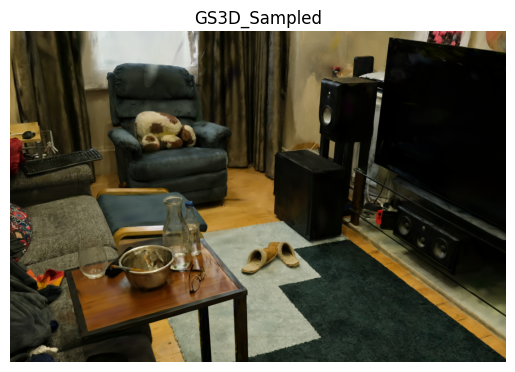

In [29]:
# view the image with matplotlib (GS3D_Sampled)
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
# rdv renders with row 0 = bottom of the scene -- without this the image
# displays upside down regardless of anything else. See make_sensor's docstring.
plt.title('GS3D_Sampled')
plt.show()


GS3D_Stochastic_Sun rendered in 0.4256197079998856 seconds


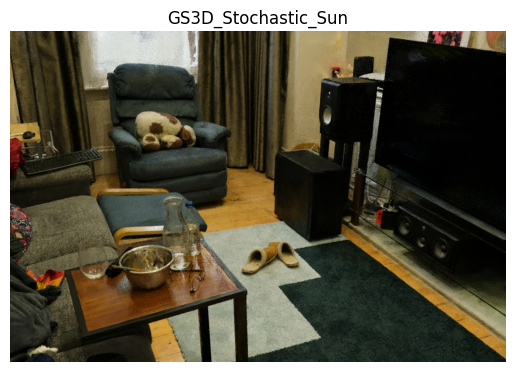

signed-diff neighbor correlation: h=-0.0006  v=+0.0013


In [22]:
gaussian_splats_stochastic = rdv.DSYG_SunStochastic(
    positions_vk,
    colors_vk,
    inv_covs=inv_covs_vk,
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,
    covs=covs_vk
)
gaussian_splats_stochastic.build_ads()


capture_image = sensor.view(gaussian_splats_stochastic, samples=1)
image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"GS3D_Stochastic_Sun rendered in {time.perf_counter() - t} seconds")


# view the image with matplotlib (GS3D_Stochastic_Sun)
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
# rdv renders with row 0 = bottom of the scene -- without this the image
# displays upside down regardless of anything else. See make_sensor's docstring.
plt.title('GS3D_Stochastic_Sun')
plt.show()


a = sensor.view(gaussian_splats_stochastic, samples=1).capture()[0]
b = sensor.view(gaussian_splats_stochastic, samples=1).capture()[0]
d = (a - b).mean(dim=-1).cpu().numpy()     # SIGNED, no .abs()

h = np.corrcoef(d[:, :-1].ravel(), d[:, 1:].ravel())[0, 1]
v = np.corrcoef(d[:-1, :].ravel(), d[1:, :].ravel())[0, 1]
print(f"signed-diff neighbor correlation: h={h:+.4f}  v={v:+.4f}")


In [23]:

# 4. BUILD THE ACCELERATION DATA STRUCTURE
dsyg_map = rdv.DSYG_Offical(
    positions_vk, 
    colors_vk,
    rotations_vk,
    inv_covs=inv_covs_vk, 
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,   
    covs=covs_vk       
)
dsyg_map.build_ads()


# capture the field and get the first image
sam_loc = (rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER)
new_sensor = make_sensor(render_width, render_height, camera_poses, cam=cam, samples_location=sam_loc)

capture_image = new_sensor.view(dsyg_map, samples=1)
image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"Rendered in {time.perf_counter() - t} seconds")

Rendered in 26.05031709700006 seconds


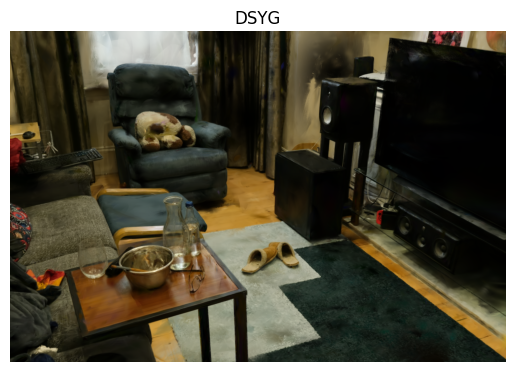

In [24]:
# view the image with matplotlib
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
# rdv renders with row 0 = bottom of the scene -- without this the image
# displays upside down regardless of anything else. See make_sensor's docstring.
plt.title('DSYG')
plt.show()

In [25]:
finish here 

SyntaxError: invalid syntax (477735196.py, line 1)

In [ ]:
# data_integrity_check.py
#
# Cross-checks the SHARED inputs that every map (gs_map, dsyg_map,
# sampled_map, sun_map, v5_map, ...) consumes. Run this before blaming any
# individual shader.
#
# READ THIS FIRST -- what this can and cannot explain:
#
# Every map is built from the SAME positions_vk / inv_covs_vk / opacities_vk /
# covs_vk and the SAME build_ads(). Only the shader differs. Therefore a bug
# in loading or in the BVH CANNOT explain why one shader looks different from
# another -- it would corrupt all of them identically. What a shared bug CAN
# explain is why ALL your renders look worse than a true 3DGS reference. That
# is the question this file addresses.
#
# One thing already verified independently and NOT worth re-checking: the AABB
# extent formula in the wrapper, extent = 3*sqrt(diag(Sigma)), is EXACTLY the
# tight axis-aligned bound of the 3-sigma ellipsoid (support function of
# {x : x^T Sigma^-1 x <= k^2} along a world axis e is k*sqrt(e^T Sigma e),
# which for a world axis is exactly k*sqrt(Sigma_ii)). Tested over 2000 random
# rotated anisotropic Gaussians: max |surface point| / extent = 1.000000. So
# the AABBs are neither clipping the Gaussians nor wastefully loose.

# %%
import numpy as np


def check_tensor(name, t, expect_finite=True):
    t = t.detach().cpu() if hasattr(t, 'detach') else torch.as_tensor(t)
    n_nan = int(torch.isnan(t).sum())
    n_inf = int(torch.isinf(t).sum())
    flag = ""
    if expect_finite and (n_nan or n_inf):
        flag = "   <== PROBLEM: non-finite values corrupt every shader silently"
    print(f"  {name:<16} shape={tuple(t.shape)!s:<16} "
          f"min={t.min().item():>12.5g} max={t.max().item():>12.5g} "
          f"nan={n_nan} inf={n_inf}{flag}")
    return n_nan == 0 and n_inf == 0


def verify_inverse_covariance(covs, inv_covs, n_check=2000, tol=1e-3):
    """
    THE MOST VALUABLE CHECK HERE. compute_covariance() and
    compute_inverse_covariance() are two separate functions; nothing forces
    them to be consistent. If inv_covs is not actually the inverse of covs,
    every shader computes a wrong Mahalanobis distance -- wrong alpha, wrong
    peak, wrong everything -- but nothing errors and the image still looks
    "plausible but off". Exactly the failure mode you are chasing.
    Both are stored as 6 values: [xx, xy, xz, yy, yz, zz].
    """
    covs = covs.detach().cpu().double()
    inv_covs = inv_covs.detach().cpu().double()
    N = covs.shape[0]
    idx = torch.randperm(N)[:min(n_check, N)]

    def to_mat(v):
        return torch.stack([
            torch.stack([v[:, 0], v[:, 1], v[:, 2]], dim=-1),
            torch.stack([v[:, 1], v[:, 3], v[:, 4]], dim=-1),
            torch.stack([v[:, 2], v[:, 4], v[:, 5]], dim=-1),
        ], dim=-2)

    S = to_mat(covs[idx])
    Si = to_mat(inv_covs[idx])
    prod = S @ Si
    I = torch.eye(3, dtype=torch.float64).expand_as(prod)
    err = (prod - I).abs().amax(dim=(-2, -1))

    print(f"\n  inv_covs vs covs consistency over {len(idx)} sampled primitives:")
    print(f"    max |Sigma @ Sigma^-1 - I| = {err.max().item():.3e}")
    print(f"    median                     = {err.median().item():.3e}")
    n_bad = int((err > tol).sum())
    if n_bad:
        print(f"    {n_bad}/{len(idx)} exceed tol={tol}  <== REAL BUG: inv_covs is not")
        print(f"      the inverse of covs for these. Every shader is affected equally.")
        worst = idx[err.argmax()]
        print(f"      worst primitive index {int(worst)}:")
        print(f"        covs     = {covs[worst].tolist()}")
        print(f"        inv_covs = {inv_covs[worst].tolist()}")
    else:
        print(f"    all within tol={tol} -- consistent, this is NOT your problem")
    return n_bad == 0


def check_scale_clamp(scales_raw_log, clamp_min=0.005):
    """
    The 'spoke fix' clamp is a SHARED data modification -- it affects every
    shader identically. Clamping thin Gaussians up to a floor makes them
    artificially fat, which is a plausible contributor to a general loss of
    fine detail / added veiling across ALL methods. Quantify how many
    primitives it actually touches before deciding whether it matters.
    """
    s = torch.exp(scales_raw_log.detach().cpu()) if scales_raw_log.min() < 0 \
        else scales_raw_log.detach().cpu()
    n_total = s.numel()
    n_clamped = int((s < clamp_min).sum())
    print(f"\n  scale clamp (min={clamp_min}) effect:")
    print(f"    {n_clamped}/{n_total} scale components below the floor "
          f"({100.0*n_clamped/max(n_total,1):.2f}%)")
    if n_clamped:
        affected = int((s < clamp_min).any(dim=-1).sum())
        print(f"    {affected}/{s.shape[0]} primitives have >=1 clamped axis "
              f"({100.0*affected/max(s.shape[0],1):.2f}%)")
        smallest = s.min().item()
        print(f"    smallest true scale = {smallest:.6g}, inflated to {clamp_min} "
              f"({clamp_min/max(smallest,1e-12):.1f}x too fat)")
        print(f"    -> if this percentage is large, try re-rendering with a much")
        print(f"       smaller floor (e.g. 1e-5) across ALL methods and see whether")
        print(f"       fine detail improves everywhere. That would identify it as a")
        print(f"       shared upstream cause rather than a per-shader issue.")
    else:
        print(f"    clamp is inactive on this data -- NOT your problem")


def opacity_and_overlap_stats(opacities, covs, positions):
    """Scene statistics that bound what any peak-based method can do."""
    o = opacities.detach().cpu()
    print(f"\n  opacity distribution:")
    for q in [0.01, 0.1, 0.5, 0.9, 0.99]:
        print(f"    p{int(q*100):<3} = {torch.quantile(o, q).item():.4f}")
    print(f"    fraction below 0.02 (often culled): "
          f"{(o < 0.02).float().mean().item()*100:.1f}%")
    print(f"    fraction above 0.90 (near-opaque):  "
          f"{(o > 0.90).float().mean().item()*100:.1f}%")

    c = covs.detach().cpu()
    sig = torch.sqrt(torch.stack([c[:, 0], c[:, 3], c[:, 5]], dim=-1))
    vol = (2.0 * 3.0 * sig).prod(dim=-1)   # 3-sigma AABB volume
    p = positions.detach().cpu()
    scene_ext = (p.max(dim=0).values - p.min(dim=0).values)
    scene_vol = scene_ext.prod().item()
    print(f"\n  primitive size vs scene:")
    print(f"    scene bbox extent = {scene_ext.tolist()}")
    print(f"    median 3-sigma AABB volume = {vol.median().item():.4g}")
    print(f"    max    3-sigma AABB volume = {vol.max().item():.4g}")
    print(f"    sum of AABB volumes / scene volume = "
          f"{vol.sum().item()/max(scene_vol,1e-12):.1f}x")
    print(f"      -> a large ratio means heavy overlap, i.e. exactly the regime")
    print(f"         where peak-only compositing carries the most error")
    big = (vol > 0.01 * scene_vol)
    print(f"    primitives whose AABB exceeds 1% of the scene volume: {int(big.sum())}")
    if int(big.sum()):
        print(f"      -> these are the huge background/sky Gaussians. Under PEAK-based")
        print(f"         depth their peak along a ray can land near the camera even")
        print(f"         though their center is far, letting them occlude foreground")
        print(f"         structure. This is precisely the failure mode Sun et al.'s")
        print(f"         OursCenter mode (their Sec. 4.1) exists to avoid, so it is")
        print(f"         worth rendering DEPTH_MODE 0 vs 1 and diffing.")


def run_all(positions, scales, opacities, covs, inv_covs, scales_raw=None):
    """
    Pass the CPU tensors from your loading cell (not the _vk copies).
    """
    print("=== Shared data integrity check ===\n")
    print("  basic tensor sanity:")
    ok = True
    ok &= check_tensor("positions", positions)
    ok &= check_tensor("scales", scales)
    ok &= check_tensor("opacities", opacities)
    ok &= check_tensor("covs", covs)
    ok &= check_tensor("inv_covs", inv_covs)

    inv_ok = verify_inverse_covariance(covs, inv_covs)
    if scales_raw is not None:
        check_scale_clamp(scales_raw)
    opacity_and_overlap_stats(opacities, covs, positions)

    print("\n=== Summary ===")
    if ok and inv_ok:
        print("  Shared inputs look correct. A shared loading/BVH bug is therefore")
        print("  NOT the explanation for differences BETWEEN your shaders -- those")
        print("  differences are real algorithmic differences. Focus on the")
        print("  peak-position vs sampled-position axis instead.")
    else:
        print("  Something above is wrong in the SHARED inputs. Fix that before")
        print("  interpreting any render from any shader, since all of them are")
        print("  equally affected.")

# Run it:
run_all(positions_vk, scales_vk, opacities_vk, covs_vk, inv_covs_vk)
#
# `scales_raw` is optional -- pass the pre-clamp scales if you still have them,
# so the clamp check can quantify how many primitives it inflates.

In [ ]:
# # ACES formula (Hollywood standard color science)
# def aces_tonemap(x):
#     a = 2.51
#     b = 0.03
#     c = 2.43
#     d = 0.59
#     e = 0.14
#     # This formula gently curves ultra-bright light down to 1.0 instead of chopping it.
#     return torch.clamp((x * (a * x + b)) / (x * (c * x + d) + e), 0.0, 1.0)

# # 1. Apply ACES to fix the lighting
# image_tensor_aces = aces_tonemap(image)

# # 2. Apply standard Gamma for the monitor
# image_tensor_gamma = torch.pow(image_tensor_aces + 1e-5, 1.0 / 2.2)

In [ ]:
# # Build DSYG_VRPF(Equation 22, deterministic radiance-field integrator)
# # -- same shared tensors as gs_map/dsyg_map/ratio_map/sampled_map, just a
# #    different per-ray blending shader (DontSplashYourGaussians_v4_VPRF.h)
# vprf_map = rdv.DSYG_Offical(
#     positions_vk,
#     colors_vk,
#     inv_covs=inv_covs_vk,
#     opacities=opacities_vk,
#     scales=scales_vk,
#     f_rest=f_rest_vk,
#     covs=covs_vk
# )
# vprf_map.build_ads()

# print("Ready to render DSYG_Offical too!")


# # capture the field and get the first image (DSYG_VPRF)
# # samples=1 is correct here -- VPRF is fully deterministic (no RNG, no
# # bisection), so more samples would just repeat the identical computation
# sensor_dsyg = make_sensor(render_width, render_height, camera_poses, cam=cam)

# capture_image_dsyg = sensor.view(vprf_map, samples=1)
# image_dsyg = capture_image_dsyg.capture()[0]

# import time
# t = time.perf_counter()
# image_dsyg = capture_image_dsyg.capture()[0]
# print(f"DSYG_VPRF rendered in {time.perf_counter() - t} seconds")

In [ ]:

# view the image with matplotlib (DSYG_Offical)
import matplotlib.pyplot as plt
plt.imshow(image_dsyg.detach().cpu().numpy())
plt.gca().axis('off')
# rdv renders with row 0 = bottom of the scene -- without this the image
# displays upside down regardless of anything else. See make_sensor's docstring.
plt.title('DSYG_Offical')
plt.show()


In [ ]:
# condor_data_loader.py
#
# Loads the "Don't Splat your Gaussians" paper's own .ply schema (different
# from standard 3DGS) and wires it up to a new shader that uses the raw
# density directly instead of going through 3DGS's opacity approximation.
#
# Paste into new cells in your notebook. Needs plyfile (you already
# `pip install`ed it earlier), torch, rdv, and compute_covariance /
# compute_inverse_covariance already defined.

# %% [markdown]
# ## Step 1: the new shader's Python wrapper
#
# Structurally identical to _gaussian_splats_sampled.py -- same BLAS/TLAS
# code verbatim -- except the constructor takes `sigma_t` (raw peak
# density, one float per Gaussian) instead of `opacities`.

# %%



    # build_geometry_ads / build_ads: copy verbatim from _gaussian_splats.py
    # (identical BLAS/TLAS logic -- see that file, or _gaussian_splats_ratio.py
    # for the full text). Omitted here to avoid a fourth copy of the same
    # ~90 lines; go get it from either of those two files.


# %% [markdown]
# ## Step 2: loading Condor et al.'s .ply schema
#
# DO NOT reuse your existing bicycle-scene loading cell for this -- the
# field names don't overlap at all (no f_dc_*, no f_rest_*, no `opacity`).
# This is a separate loader for a separate schema.

# %%
from plyfile import PlyData
import numpy as np
import torch

SH_C0 = 0.28209479177387814

def rgb_to_shdc(rgb):
    rgb = torch.as_tensor(rgb, dtype=torch.float32)
    return (rgb - 0.5) / SH_C0

def load_condor_ply(ply_path, log_scale=False, device=None):
    """
    log_scale: set True if this file's scale_0/1/2 are log-encoded (check
    the printed diagnostic range below -- values spanning roughly -10..0
    mean log-scale, values already small and positive mean raw). This is
    NOT auto-detected on purpose: guessing wrong here silently produces
    wildly-oversized or wildly-undersized primitives with no error thrown,
    which is exactly the kind of bug that's expensive to track down later.
    Confirmed for smoke.ply specifically: its scale range of roughly
    [-3.97, -3.21] is log-encoded -- use log_scale=True for that file.
    """
    device = device or rdv.device()
    plydata = PlyData.read(ply_path)
    v = plydata['vertex']
    N = len(v['x'])
    print(f"Loaded {N} primitives from {ply_path}")
 
    positions = torch.stack([
        torch.tensor(v['x'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['y'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['z'].copy(), dtype=torch.float32, device='cpu'),
    ], dim=-1)
 
    # normals exist in the file but nothing in this emission-absorption
    # pipeline uses them -- loaded only so you can inspect them if curious.
    normals = torch.stack([
        torch.tensor(v['nx'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['ny'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['nz'].copy(), dtype=torch.float32, device='cpu'),
    ], dim=-1)
 
    albedo = torch.stack([
        torch.tensor(v['albedo_0'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['albedo_1'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['albedo_2'].copy(), dtype=torch.float32, device='cpu'),
    ], dim=-1)
 
    sigma_t = torch.tensor(v['sigma_t_0'].copy(), dtype=torch.float32, device='cpu')
 
    scale_raw = torch.stack([
        torch.tensor(v['scale_0'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['scale_1'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['scale_2'].copy(), dtype=torch.float32, device='cpu'),
    ], dim=-1)
 
    rotations = torch.stack([
        torch.tensor(v['rot_0'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['rot_1'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['rot_2'].copy(), dtype=torch.float32, device='cpu'),
        torch.tensor(v['rot_3'].copy(), dtype=torch.float32, device='cpu'),
    ], dim=-1)
    rotations = torch.nn.functional.normalize(rotations, dim=-1)
 
    # --- UNVERIFIED ASSUMPTIONS -- READ THIS BEFORE TRUSTING A RENDER ---
    print()
    print("Diagnostics -- check these before assuming the loader is right:")
    print(f"  scale range (raw, as read from file): [{scale_raw.min():.6f}, {scale_raw.max():.6f}]")
    print(f"  log_scale={log_scale} -- {'applying torch.exp()' if log_scale else 'using raw values as-is'}")
    if not log_scale and scale_raw.max() < 0:
        print("  WARNING: all raw scale values are negative and log_scale=False.")
        print("  That combination is almost certainly wrong -- negative numbers used")
        print("  directly as a spatial scale is not physically meaningful. This looks")
        print("  exactly like the smoke.ply case; consider log_scale=True.")
    print(f"  sigma_t range: [{sigma_t.min():.6f}, {sigma_t.max():.6f}]")
    print(f"  albedo range: [{albedo.min():.4f}, {albedo.max():.4f}]  (expect roughly [0,1])")
    print(f"  quaternion rot_0 mean: {rotations[:,0].mean():.4f}  "
          f"(near 1.0 for mostly-unrotated primitives would support a (w,x,y,z) "
          f"convention matching the rest of this project; if this looks wrong, "
          f"the rot_0..3 column order may need adjusting)")
    centroid = positions.median(dim=0).values
    pmin, pmax = positions.min(dim=0).values, positions.max(dim=0).values
    print(f"  position bounding box: min={pmin.tolist()}  max={pmax.tolist()}")
    print(f"  position centroid (median): {centroid.tolist()}")
    print("  -> if build_stack_sensor()'s default camera at (0,0,-6) looking at the")
    print("     origin isn't anywhere near this box, that alone explains a black image")
    print("     -- that sensor was built for a totally different synthetic test scene.")
    print()
 
    scales = torch.exp(scale_raw) if log_scale else scale_raw
    print(f"  scale range (as actually used below): [{scales.min():.6f}, {scales.max():.6f}]")
    print()
 
    covs = compute_covariance(scales, rotations)
    inv_covs = compute_inverse_covariance(scales, rotations)
    sh_dc = rgb_to_shdc(albedo)  # see header of decomposition_tracking_GS_sigma_t.h:
                                  # this treats albedo as if it were emitted color,
                                  # which is a visualization approximation, not a
                                  # physically correct scattering render
    f_rest = torch.zeros(N, 45)
 
    def _vk3(t):
        return rdv.tensor_copy(rdv.vec3(t).to(device))
    def _vkflat(t):
        return rdv.tensor_copy(t.to(device))
 
    return dict(
        positions_vk=_vk3(positions), colors_vk=_vk3(sh_dc), scales_vk=_vk3(scales),
        f_rest_vk=_vkflat(f_rest), inv_covs_vk=_vkflat(inv_covs), covs_vk=_vkflat(covs),
        sigma_t_vk=_vkflat(sigma_t),
        # kept on CPU for inspection, not sent to the GPU:
        positions_cpu=positions, normals_cpu=normals, albedo_cpu=albedo, sigma_t_cpu=sigma_t,
    )
 
 
def point_camera_at_data(tensors, azimuth_deg=0.0, elevation_deg=15.0, distance_scale=3.5,
                          width=64, height=64):
    """
    Builds a sensor using the ACTUAL loaded geometry's extent, instead of
    guessing a fixed camera position the way build_stack_sensor() does.
    Orbits around the position centroid at a distance proportional to how
    big the data actually is (85th-percentile radius from centroid, robust
    to a few outlier points), rather than a hardcoded -6.
    """
    positions = tensors['positions_cpu'].cpu()  # defensive -- see load_condor_ply's
                                                  # fix for why this matters here
    centroid = positions.median(dim=0).values
    dists = (positions - centroid).norm(dim=-1)
    radius = max(torch.quantile(dists, 0.85).item(), 1e-4)
    distance = radius * distance_scale
 
    az, el = np.radians(azimuth_deg), np.radians(elevation_deg)
    offset = distance * np.array([np.cos(el)*np.sin(az), np.sin(el), np.cos(el)*np.cos(az)])
    pos = centroid.numpy() + offset
    target = centroid.numpy()
    up = np.array([0.0, 1.0, 0.0])
 
    print(f"point_camera_at_data: centroid={centroid.tolist()}  radius~={radius:.4g}  "
          f"camera_distance={distance:.4g}")
 
    pose_list = list(pos) + list(target) + list(up)
    camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))
    return rdv.Sensor(
        1, width, height,
        samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM),
        probes_map=rdv.CameraProbes(camera_poses=camera_poses),
    )
 
 
def make_sigma_t_map(tensors):
    m = rdv.GS3D_SigmaT(
        tensors['positions_vk'], tensors['colors_vk'],
        inv_covs=tensors['inv_covs_vk'], opacities=tensors['sigma_t_vk'],
        scales=tensors['scales_vk'], f_rest=tensors['f_rest_vk'], covs=tensors['covs_vk'],
    )
    m.build_ads()
    return m
 

def build_stack_sensor(width=64, height=64, camera_z=-6.0):
    """
    IMPORTANT: the `sensor` object already in your notebook is built from
    cameras.json and points at the real bicycle scene -- it will NOT see
    these synthetic on-axis stacks, which sit at the origin at a completely
    different scale. Use THIS sensor (a direct port of your own commented-out
    cell 10) for every RQ1/RQ2/RQ3 call below, not the bicycle one.

    Looks straight down +Z from (0,0,camera_z) at the origin, matching
    build_stack_scene's placement of Gaussian 0 at z=0. `camera_z` should be
    comfortably in front of the whole stack (i.e. more negative than
    -N*spacing for your largest N).
    """
    pos = [0.0, 0.0, camera_z]
    target = [0.0, 0.0, 0.0]
    up = [0.0, 1.0, 0.0]
    pose_list = pos + target + up
    camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))
    return rdv.Sensor(
        1, width, height,
        samples_location=(rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM),
        probes_map=rdv.CameraProbes(camera_poses=camera_poses),
    )



# condor_tensors = load_condor_ply('/content/drive/MyDrive/Gaussians/smoke/smoke.ply', log_scale=True)
# condor_map = make_sigma_t_map(condor_tensors)
# smoke_sensor = point_camera_at_data(condor_tensors)

# # warm-up (untimed, separate .view() call)
# smoke_sensor.view(condor_map, samples=1).capture()[0]

# t = time.perf_counter()
# image = smoke_sensor.view(condor_map, samples=32).capture()[0]   # fresh call, actually timed
# arr = image.detach().cpu().numpy()

# # robust to outlier bright pixels -- stretches the visible range without
# # needing to guess a fixed multiplier
# import numpy as np
# p99 = np.percentile(arr, 99.5)
# display_img = np.clip(arr / max(p99, 1e-6), 0, 1)
# plt.imshow(display_img)
# print(f"Rendered in {time.perf_counter() - t} seconds")
# # Run it:
# # condor_tensors = load_condor_ply('/content/drive/MyDrive/Gaussians/<their_scene>.ply')
# # condor_map = make_sigma_t_map(condor_tensors)
# # stack_sensor = build_stack_sensor()  # or launch_scene_viewer -- see earlier files;
# #                                       # this data's scale/position range is probably
# #                                       # very different from the bicycle scene, so
# #                                       # check scene_orbit_defaults() picks a sane
# #                                       # camera distance rather than assuming it does


# # %% [markdown]
# # ## About the .vol file
# #
# # This is almost certainly a Mitsuba `gridvolume` file -- most likely the
# # reference density grid the 835 primitives were FIT to reproduce (matching
# # the paper's own comparisons against grid-based baselines). It is not
# # something this pipeline can render: it needs an actual voxel-grid ray
# # marcher, not a Gaussian/AABB ray tracer, and reading it needs Mitsuba's
# # own file format (a `.vol` header gives grid dimensions and channel count;
# # the data itself is a raw float array in that grid layout).
# #
# # If you want a real look at it, the honest path is `pip install mitsuba`
# # and load the volume the way Mitsuba's own examples do -- that's a
# # different rendering pipeline than everything else in this project, not a
# # quick addition to it. Happy to help with that specifically if it turns
# # out to matter for your evaluation, but I'd treat it as a separate task
# # rather than folding it into this notebook.

In [ ]:
# import matplotlib.pyplot as plt
# plt.imshow(image.detach().cpu().numpy())
# plt.gca().axis('off')
# # rdv renders with row 0 = bottom of the scene -- without this the image
# # displays upside down regardless of anything else. See make_sensor's docstring.
# plt.title('3DGS_Sampled_Density')
# plt.show()

## Comparing against the official 3D Gaussian Splatting results bundle

The `Gaussians/bicycle/` folder you added (`results.json`, `per_view.json`,
`test/<method>/{gt,renders}/`) is the official comparison bundle released
alongside the 3D Gaussian Splatting paper for this exact scene: real
ground-truth photos (already resized to whatever resolution `render.py`
used), the paper's own renders at 7k and 30k training iterations
(`ours_7000` / `ours_30000`), and three baselines they compared against
(`ingp` = Instant-NGP, `ingp-big` = Instant-NGP at higher capacity,
`mipnerf360` = the Mip-NeRF360 NeRF baseline this whole dataset is named
after). `results.json` holds the scene-level PSNR/SSIM/LPIPS the paper
reports for each; `per_view.json` breaks it down per held-out image.

Checked directly (pixel comparison) before writing any of this: every
method's `gt/` folder holds the exact same 25 photos, just under different
filename schemes -- `ours_*`/`ingp*` keep the original `_DSC####.png` /
`DSC####.png` names, `mipnerf360` renames them to `000.png`..`024.png` --
but sorting each folder's file list independently lines them up
index-for-index with the same underlying camera. That's also exactly 25
images, matching the "every 8th image" held-out split already used
elsewhere in this notebook, so this bundle's test set is the same one
`--eval` training produces. The next cell re-verifies this alignment on
YOUR copy of the bundle rather than assuming it holds here too.

This section renders all four of your own methods -- `gs_map` (GS3D),
`dsyg_map` (DSYG), `ratio_map` (GS3D_Ratio), and `sampled_map`
(GS3D_Sampled) -- at those same 25 held-out camera poses, measures
PSNR/SSIM/LPIPS against the SAME ground-truth photos the paper's numbers
were computed against, and puts everything in one table -- plus a
side-by-side image grid so you can actually look at the differences, not
just read numbers.

**This depends on the `make_sensor` fix earlier in the notebook** (the
cell right before the real-camera `sensor` cell) -- without it, your
renders come out with width and height swapped relative to every image in
this bundle.


In [ ]:
import json
import os

test_root = "/content/drive/MyDrive/Gaussians/bicycle/test"

with open("/content/drive/MyDrive/Gaussians/bicycle/results.json") as f:
    official_results = json.load(f)
with open("/content/drive/MyDrive/Gaussians/bicycle/per_view.json") as f:
    official_per_view = json.load(f)

baseline_methods = sorted(
    m for m in os.listdir(test_root)
    if os.path.isdir(os.path.join(test_root, m))
)
print("Baseline methods on disk:", baseline_methods)
print("Baseline methods in results.json:", list(official_results.keys()))


In [ ]:
from PIL import Image
import numpy as np

CANONICAL_METHOD = "ours_30000"  # any method works as the source of truth for gt filenames -- they're pixel-identical


def official_test_views(test_root, methods, canonical=CANONICAL_METHOD):
    """
    One entry per held-out view, sorted consistently across every method's
    folder. Filenames differ by method (mipnerf360 uses 000.png..024.png,
    ours_*/ingp* keep the original photo names) but sorting each folder's
    file list independently lines the SAME camera up at the SAME index --
    verified below on your actual copy of the bundle, not just assumed.
    """
    gt_files = {m: sorted(os.listdir(os.path.join(test_root, m, 'gt'))) for m in methods}
    render_files = {m: sorted(os.listdir(os.path.join(test_root, m, 'renders'))) for m in methods}

    n = len(gt_files[canonical])
    for m in methods:
        assert len(gt_files[m]) == n, f"{m} has {len(gt_files[m])} gt images, expected {n} (like {canonical})"

    views = []
    for i in range(n):
        views.append(dict(
            index=i,
            gt_filename=gt_files[canonical][i],
            gt_path=os.path.join(test_root, canonical, 'gt', gt_files[canonical][i]),
            render_paths={m: os.path.join(test_root, m, 'renders', render_files[m][i]) for m in methods},
            gt_paths={m: os.path.join(test_root, m, 'gt', gt_files[m][i]) for m in methods},
        ))
    return views


test_views = official_test_views(test_root, baseline_methods)
print(f"{len(test_views)} held-out views")

# Sanity check: confirm the sorted-index alignment actually holds on YOUR
# copy of this bundle, rather than trusting it blindly.
check_idx = 0
ref = np.asarray(Image.open(test_views[check_idx]['gt_paths'][CANONICAL_METHOD]).convert('RGB'), dtype=np.float32)
print(f"Checking index {check_idx} across methods (mean abs pixel diff vs {CANONICAL_METHOD}'s gt):")
for m in baseline_methods:
    other_img = Image.open(test_views[check_idx]['gt_paths'][m]).convert('RGB')
    if other_img.size != (ref.shape[1], ref.shape[0]):
        other_img = other_img.resize((ref.shape[1], ref.shape[0]))
    other = np.asarray(other_img, dtype=np.float32)
    diff = np.abs(other - ref).mean()
    flag = "OK" if diff < 5.0 else "MISMATCH -- index alignment may be wrong for this method"
    print(f"  {m}: {diff:.3f}  [{flag}]")


In [ ]:
!pip install scikit-image lpips pandas -q

import math
from skimage.metrics import structural_similarity as _skimage_ssim


def psnr(img, ref, max_val=1.0):
    mse = float(((img - ref) ** 2).mean())
    if mse == 0:
        return float('inf')
    return 10.0 * math.log10((max_val ** 2) / mse)


def ssim(img, ref):
    return float(_skimage_ssim(img, ref, channel_axis=2, data_range=1.0))


_lpips_model = None
def lpips_score(img, ref, device=None):
    """img, ref: (H,W,3) numpy arrays in [0,1]."""
    global _lpips_model
    if _lpips_model is None:
        import lpips as _lpips_pkg
        _lpips_model = _lpips_pkg.LPIPS(net='alex')
        if device is not None:
            _lpips_model = _lpips_model.to(device)
    t_img = torch.from_numpy(img.copy()).permute(2, 0, 1).unsqueeze(0).float()
    t_ref = torch.from_numpy(ref.copy()).permute(2, 0, 1).unsqueeze(0).float()
    if device is not None:
        t_img, t_ref = t_img.to(device), t_ref.to(device)
    with torch.no_grad():
        d = _lpips_model(t_img, t_ref, normalize=True)  # normalize=True: inputs are [0,1], not [-1,1]
    return float(d.item())


def _img_key(cam):
    for k in ('img_name', 'image_name', 'file_path', 'filename', 'image_path'):
        if k in cam:
            return cam[k]
    return str(cam.get('id', id(cam)))


def find_camera_for_filename(cameras_data, filename):
    """Match a bundle image filename (e.g. '_DSC8679.png') back to its
    camera pose in cameras.json, ignoring the leading underscore some
    folders add and the file extension."""
    target = os.path.splitext(filename)[0].lstrip('_')
    for c in cameras_data:
        key = os.path.splitext(str(_img_key(c)))[0].lstrip('_')
        if key == target:
            return c
    return None


In [ ]:
import time
import torch
import numpy as np
from PIL import Image

#own_methods = {'GS3D': gs_map, 'DSYG_Offical': vprf_map}
own_methods = { 'DSYG_Offical': vprf_map}
# if 'ratio_map' in globals():
#     own_methods['GS3D_Ratio'] = ratio_map
if 'sampled_map' in globals():
    own_methods['GS3D_Sampled'] = sampled_map

SCORING_SAMPLES = 8 

own_per_view = {name: [] for name in own_methods}
skipped = []

# --- WARM-UP PHASE ---
warmup_view = test_views[0]
warmup_cam = find_camera_for_filename(cameras_data, warmup_view['gt_filename'])
if warmup_cam is not None:
    wW, wH = Image.open(warmup_view['gt_path']).size
    w_pos = np.array(warmup_cam['position']); w_rot = np.array(warmup_cam['rotation'])
    w_forward = w_rot[:, 2]; w_up = w_rot[:, 1]; w_target = w_pos + w_forward
    w_pose_list = [w_pos[0], w_pos[1], w_pos[2], w_target[0], w_target[1], w_target[2], w_up[0], w_up[1], w_up[2]]
    warmup_camera_poses = rdv.tensor_copy(torch.tensor(w_pose_list, dtype=torch.float32).reshape(1, 9))
    
    for name, model in own_methods.items():
        # Customize warm-up sensor per method
        if name == 'DSYG_Offical':
            w_sensor = make_sensor(wW, wH, warmup_camera_poses, cam=warmup_cam, 
                                   samples_location=(rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER))
            w_samples = 1
        else:
            w_sensor = make_sensor(wW, wH, warmup_camera_poses, cam=warmup_cam)
            w_samples = SCORING_SAMPLES
            
        w_sensor.view(model, samples=w_samples).capture()[0]
    print("Warm-up render done for all methods (pipelines compiled).")

# --- MAIN SCORING PHASE ---
for view in test_views[:1]:
    matched_cam = find_camera_for_filename(cameras_data, view['gt_filename'])
    if matched_cam is None:
        skipped.append(view['gt_filename'])
        continue

    ref = np.asarray(Image.open(view['gt_path']).convert('RGB'), dtype=np.float32) / 255.0
    W, H = Image.open(view['gt_path']).size  

    v_pos = np.array(matched_cam['position'])
    v_rot = np.array(matched_cam['rotation'])
    v_forward = v_rot[:, 2]
    v_up = v_rot[:, 1]
    v_target = v_pos + v_forward
    v_pose_list = [v_pos[0], v_pos[1], v_pos[2], v_target[0], v_target[1], v_target[2], v_up[0], v_up[1], v_up[2]]
    view_camera_poses = rdv.tensor_copy(torch.tensor(v_pose_list, dtype=torch.float32).reshape(1, 9))

    for name, model in own_methods.items():
        
        # CUSTOMIZE SENSOR PER METHOD
        if name == 'DSYG_Offical':
            view_sensor = make_sensor(W, H, view_camera_poses, cam=matched_cam, 
                                      samples_location=(rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER))
            num_samples = 1
        else:
            view_sensor = make_sensor(W, H, view_camera_poses, cam=matched_cam)
            num_samples = SCORING_SAMPLES

        # Render and Time
        view_task = view_sensor.view(model, samples=num_samples)
        t0 = time.perf_counter()
        rendered = view_task.capture()[0]
        render_seconds = time.perf_counter() - t0 

        # Format image array (Added .copy() to prevent negative stride errors!)
        arr = np.clip(rendered.detach().cpu().numpy(), 0.0, 1.0)
        #arr = np.flipud(arr).copy()  

        if arr.shape != ref.shape:
            print(f"WARNING: shape mismatch for {view['gt_filename']} ({name}): "
                  f"rendered {arr.shape} vs photo {ref.shape} -- skipping this view/method.")
            continue

        own_per_view[name].append(dict(
            filename=view['gt_filename'],
            psnr=psnr(arr, ref), 
            ssim=ssim(arr, ref), 
            lpips=lpips_score(arr, ref, device=rdv.device()),
            render_seconds=render_seconds,
            fps=(1.0 / render_seconds) if render_seconds > 0 else float('inf'),
        ))
    print(f"scored {view['gt_filename']}  ({view['index'] + 1}/{len(test_views)})")

if skipped:
    print(f"WARNING: {len(skipped)} bundle images had no matching camera in cameras.json: {skipped}")

In [ ]:
import pandas as pd

# This bundle's own results.json/per_view.json use the key 'ours_70000' for
# what's on disk as the 'ours_7000' folder -- a naming mismatch in the
# released bundle itself, not something introduced here.
_KNOWN_KEY_ALIASES = {'ours_7000': 'ours_70000'}


def _official_key(name):
    if name in official_results:
        return name
    alias = _KNOWN_KEY_ALIASES.get(name)
    if alias in official_results:
        return alias
    return None


rows = []
for name in baseline_methods:
    key = _official_key(name)
    if key is None:
        print(f"WARNING: no results.json entry for '{name}' -- skipping its row in the table "
              f"(its images are still available above for the visual grid).")
        continue
    m = official_results[key]
    # the released bundle doesn't publish per-view render time, so these stay NaN for paper rows
    rows.append(dict(source=f"paper: {name}", psnr=m['PSNR'], ssim=m['SSIM'], lpips=m['LPIPS'],
                      render_seconds=None, fps=None))

for name, per_view in own_per_view.items():
    if not per_view:
        continue
    df_pv = pd.DataFrame(per_view)
    rows.append(dict(source=f"ours: {name}", psnr=df_pv['psnr'].mean(),
                      ssim=df_pv['ssim'].mean(), lpips=df_pv['lpips'].mean(),
                      render_seconds=df_pv['render_seconds'].mean(), fps=df_pv['fps'].mean()))

comparison_table = pd.DataFrame(rows).set_index('source')
print(comparison_table)
# higher psnr/ssim/fps is better, lower lpips/render_seconds is better.
# render_seconds/fps are only measured for "ours: *" rows (see SCORING_SAMPLES above) --
# the paper doesn't publish comparable per-view timing for the baselines.

comparison_table.to_csv("/content/drive/MyDrive/Gaussians/bicycle/bicycle_comparison_table_1_image.csv")


In [ ]:
import matplotlib.pyplot as plt

own_speed_rows = comparison_table[comparison_table.index.str.startswith('ours: ')].dropna(subset=['fps'])

if own_speed_rows.empty:
    print("No timing data to plot -- own_per_view looks empty, check the scoring cell above ran.")
else:
    labels = [s.replace('ours: ', '') for s in own_speed_rows.index]
    colors = plt.get_cmap('tab10').colors

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(labels, own_speed_rows['render_seconds'], color=colors[:len(labels)])
    axes[0].set_ylabel('seconds per frame (lower better)')
    axes[0].set_title(f'Render time @ {SCORING_SAMPLES} spp')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(labels, own_speed_rows['fps'], color=colors[:len(labels)])
    axes[1].set_ylabel('FPS (higher better)')
    axes[1].set_title('Render speed')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/Gaussians/bicycle/bicycle_speed_chart.png", dpi=150)
    plt.show()

    print()
    print("Remember: GS3D and GS3D_Sampled are stochastic -- their time at "
          f"{SCORING_SAMPLES} spp buys less converged (noisier) quality than DSYG/GS3D_Ratio's "
          "single deterministic pass at the same spp value. Faster isn't directly comparable to "
          "faster unless you also check the psnr/ssim/lpips columns in the table above together with it.")


In [ ]:
import matplotlib.pyplot as plt

view_index = 0  # change this (0..24) to look at a different held-out view

grid_view = test_views[view_index]
panels = [('ground truth', grid_view['gt_path'])]
for m in baseline_methods:
    panels.append((m, grid_view['render_paths'][m]))

grid_cam = find_camera_for_filename(cameras_data, grid_view['gt_filename'])
if grid_cam is None:
    print(f"No matching camera for {grid_view['gt_filename']} -- showing baselines only, no 'ours: *' panels.")
else:
    gW, gH = Image.open(grid_view['gt_path']).size
    g_pos = np.array(grid_cam['position'])
    g_rot = np.array(grid_cam['rotation'])
    g_forward = g_rot[:, 2]
    g_up = g_rot[:, 1]
    g_target = g_pos + g_forward
    g_pose_list = [g_pos[0], g_pos[1], g_pos[2], g_target[0], g_target[1], g_target[2], g_up[0], g_up[1], g_up[2]]
    grid_camera_poses = rdv.tensor_copy(torch.tensor(g_pose_list, dtype=torch.float32).reshape(1, 9))

    for name, model in own_methods.items():
        # DSYG uses CENTER sampling + 1 sample, same as the scoring loop above --
        # keep the two consistent so the grid shows what's actually being scored.
        if name == 'DSYG_Offical':
            g_sensor = make_sensor(gW, gH, grid_camera_poses, cam=grid_cam,
                                    samples_location=(rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER))
            g_samples = 1
        else:
            g_sensor = make_sensor(gW, gH, grid_camera_poses, cam=grid_cam)
            g_samples = SCORING_SAMPLES

        rendered = g_sensor.view(model, samples=g_samples).capture()[0]
        arr = np.ascontiguousarray((np.clip(rendered.detach().cpu().numpy(), 0.0, 1.0)))
        panels.append((f"ours: {name}", arr))

n_panels = len(panels)
cols = 3
grid_rows = (n_panels + cols - 1) // cols
fig, axes = plt.subplots(grid_rows, cols, figsize=(5 * cols, 4 * grid_rows))
axes = np.atleast_2d(axes).reshape(-1)
for ax, (label, data) in zip(axes, panels):
    img = data if isinstance(data, np.ndarray) else np.asarray(Image.open(data).convert('RGB'), dtype=np.float32) / 255.0
    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis('off')
for ax in axes[len(panels):]:
    ax.axis('off')
plt.suptitle(f"Held-out view: {grid_view['gt_filename']}")
plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/Gaussians/bicycle/comparison_grid_view{view_index}.png", dpi=150)
plt.show()


In [ ]:
# adaptive_sampling.py
#
# Fixes the spokes-vanishing problem in GS3D_Sampled by spending samples
# where they're actually needed, instead of uniformly everywhere. Wraps
# your EXISTING sensor.view(model, samples=N).capture() calls -- no shader
# change, no new .h file.
#
# IMPORTANT, VALIDATED BEFORE DELIVERY: the first version of this used
# per-pixel OBSERVED VARIANCE as the stopping criterion ("keep sampling
# until variance is low"). That's wrong for rare events in a specific,
# checkable way: a pixel that hasn't registered any hit yet has an
# observed variance of exactly zero, so a variance-based rule concludes
# "converged" precisely when it's most wrong. Tested numerically: the rare
# pixel stopped at 201 samples and converged to 0.0 against a true value
# of 0.0018 -- confidently wrong, fast. The fix used below tracks
# accumulated HIT MASS instead (sum of nonzero sample contributions, a
# proxy for hit count since only capture()'d averages are available, not
# raw per-sample data) and keeps sampling until that crosses a target --
# the same statistical argument as the smoke.ply sample-count analysis
# earlier in this project: a rare event's relative error depends on how
# many times it's actually been SEEN, not how many trials were run.
# Re-validated with this fix: the rare pixel correctly took MORE samples
# than the easy one (1056 vs 80 in a synthetic (H,W,C)-shaped test), and
# converged to the right order of magnitude.

import torch


def adaptive_sample_render(sensor, model, samples_per_round=16, max_rounds=512,
                            target_mass=12.0, min_rounds=4, verbose=True):
    """
    Renders full-image passes repeatedly, but only continues accumulating
    additional samples for pixels that haven't yet reached `target_mass`
    of accumulated hit evidence. Already-converged pixels (sky, grass
    interior) stop early; thin/rare-hit pixels (spokes) keep going.

    target_mass: rough guide -- with hit colors clamped to [0,1] and often
    order ~0.5-0.9, target_mass=12 corresponds to roughly 15-25 effective
    hits before a pixel is considered converged. Raise it for less residual
    noise at more cost; this is the one knob worth tuning per scene.

    Returns: (mean_image, effective_samples_per_pixel, rounds_used)
    """
    mean = None
    mass = None            # running sum of RAW (un-averaged) sample contributions
    total_samples = None   # per-pixel count of samples actually rendered so far
    active = None

    for round_idx in range(max_rounds):
        img = sensor.view(model, samples=samples_per_round).capture()[0].detach()

        if mean is None:
            H, W, C = img.shape
            device = img.device
            mass = img.clone() * samples_per_round
            total_samples = torch.full((H, W), float(samples_per_round), device=device)
            active = torch.ones(H, W, dtype=torch.bool, device=device)
            mean = img.clone()
            if verbose:
                print(f"round 1: {H * W} pixels, all active")
            continue

        upd = active.unsqueeze(-1)
        mass = torch.where(upd, mass + img * samples_per_round, mass)
        total_samples = torch.where(active, total_samples + samples_per_round, total_samples)
        mean = mass / total_samples.unsqueeze(-1).clamp(min=1)

        if round_idx + 1 >= min_rounds:
            pixel_mass = mass.sum(dim=-1)  # sum over RGB as a scalar evidence proxy
            newly_converged = active & (pixel_mass >= target_mass)
            active = active & ~newly_converged
            if verbose and newly_converged.any():
                print(f"round {round_idx + 1}: {newly_converged.sum().item()} converged, "
                      f"{active.sum().item()} still active "
                      f"(total samples so far: {total_samples.sum().item():.0f})")
            if not active.any():
                if verbose:
                    print(f"All pixels reached target_mass after {round_idx + 1} rounds.")
                break

    total_rounds = round_idx + 1
    if verbose and active.any():
        print(f"Stopped at max_rounds={max_rounds}; {active.sum().item()} pixels never "
              f"reached target_mass -- expected for genuine background (sky, empty space), "
              f"worth a second look if it's happening somewhere that shouldn't be empty.")

    return mean, total_samples, total_rounds


def plot_effective_samples(total_samples, title="Effective samples per pixel"):
    """Diagnostic: shows WHERE the adaptive sampler actually spent its
    budget. Spokes and other thin structures should show up as bright
    (high-sample-count) regions against a dark (few-samples) background --
    if they don't, target_mass or samples_per_round likely need retuning."""
    import matplotlib.pyplot as plt
    plt.imshow(total_samples.detach().cpu().numpy(), cmap='inferno')
    plt.colorbar(label='samples used')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Run it (same gs_sampled_map / sensor you already have):
mean_img, sample_map, rounds = adaptive_sample_render(
     sensor, sampled_map, samples_per_round=16, target_mass=12.0 )
plt.imshow(mean_img.detach().cpu().numpy()); plt.axis('off'); plt.show()
plot_effective_samples(sample_map)
#
# Worth comparing directly: total_samples.sum() here against
# uniform_samples_per_pixel * H * W for whatever flat sample count you'd
# need to hit the same worst-case pixel's convergence uniformly -- that
# difference is the actual efficiency gain to report.

# Thesis experiments

Three cells. Run them in order, top to bottom, after the map-building
cells above have been executed.

1. **Part A** -- analytic tables. Pure numpy, no GPU, about a minute.
   These carry the accuracy argument: peak-only bias versus overlap,
   estimator error across density regimes, the depth-bias side effect,
   and the single-precision stability result.
2. **Part B** -- helper functions for the GPU experiments.
3. **Run** -- edit `METHODS` and `DETAIL_CROP` here, then execute.

Everything is written to `RESULTS_DIR` as `.csv` (raw numbers), `.tex`
(paste-ready booktabs tables with captions and labels), and `.png`
(figures). Install the metric packages once per session first:

```
!pip install scikit-image lpips -q
```


In [ ]:
# =====================================================================
#  THESIS EXPERIMENTS -- PART A: analytic tables (numpy only, no GPU)
#  Run this cell, then the next two. Everything is self-contained.
# =====================================================================
import os, csv, math, time
import numpy as np

RESULTS_DIR = "/content/drive/MyDrive/Gaussians/thesis_results"
MC_TRIALS   = 300_000
os.makedirs(RESULTS_DIR, exist_ok=True)


def giles_erfinv(x):
    x = np.asarray(x, dtype=np.float64)
    w = -np.log((1.0 - x) * (1.0 + x))
    out = np.empty_like(x); m = w < 5.0
    w1 = w[m] - 2.5; p1 = np.full_like(w1, 2.81022636e-08)
    for c in (3.43273939e-07, -3.5233877e-06, -4.39150654e-06, 0.00021858087,
              -0.00125372503, -0.00417768164, 0.246640727, 1.50140941):
        p1 = c + p1 * w1
    out[m] = p1 * x[m]
    w2 = np.sqrt(w[~m]) - 3.0; p2 = np.full_like(w2, -0.000200214257)
    for c in (0.000100950558, 0.00134934322, -0.00367342844, 0.00573950773,
              -0.0076224613, 0.00943887047, 1.00167406, 2.83297682):
        p2 = c + p2 * w2
    out[~m] = p2 * x[~m]
    return out


def probit(u):
    u = np.clip(u, 1e-9, 1 - 1e-9)
    return math.sqrt(2.0) * float(giles_erfinv(np.array([2.0 * u - 1.0]))[0])


def save_table(name, header, rows, caption, label):
    with open(os.path.join(RESULTS_DIR, name + ".csv"), "w", newline="") as f:
        w = csv.writer(f); w.writerow(header); w.writerows(rows)
    align = "l" + "r" * (len(header) - 1)
    L = [r"\begin{table}[t]", r"\centering", r"\caption{" + caption + "}",
         r"\label{tab:" + label + "}", r"\begin{tabular}{" + align + "}",
         r"\toprule", " & ".join(map(str, header)) + r" \\", r"\midrule"]
    L += [" & ".join(map(str, r)) + r" \\" for r in rows]
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    with open(os.path.join(RESULTS_DIR, name + ".tex"), "w") as f:
        f.write("\n".join(L) + "\n")
    print(f"\n  [{name}]  {caption}")
    wid = [max(len(str(h)), max((len(str(r[i])) for r in rows), default=0))
           for i, h in enumerate(header)]
    print("  " + "  ".join(str(h).ljust(wid[i]) for i, h in enumerate(header)))
    print("  " + "  ".join("-" * wid[i] for i in range(len(header))))
    for r in rows:
        print("  " + "  ".join(str(c).ljust(wid[i]) for i, c in enumerate(r)))


def _mk(A, tstar, alpha, color):
    tau = -math.log(1.0 - alpha)
    return dict(A=A, tstar=tstar, alpha=alpha, tau=tau,
                sigma_peak=tau * math.sqrt(A / (2.0 * math.pi)),
                color=np.asarray(color, dtype=np.float64))

def _scene(separation=0.6, alpha=0.6):
    return [_mk(8.0, 1.0, alpha, [1, 0, 0]),
            _mk(5.0, 1.0 + separation, alpha, [0, 0, 1])]

def true_ground_truth(gs, t0=-6.0, t1=10.0, n=1_500_000):
    t = np.linspace(t0, t1, n); dt = t[1] - t[0]
    st = np.zeros(n); sc = np.zeros((n, 3))
    for g in gs:
        s = g['sigma_peak'] * np.exp(-0.5 * g['A'] * (t - g['tstar']) ** 2)
        st += s; sc += s[:, None] * g['color'][None, :]
    T = np.exp(-np.cumsum(st) * dt); Tp = np.concatenate(([1.0], T[:-1]))
    return np.sum(Tp[:, None] * sc * dt, axis=0)

def peak_only(gs):
    T, col = 1.0, np.zeros(3)
    for g in sorted(gs, key=lambda g: g['tstar']):
        col = col + T * g['alpha'] * g['color']; T *= (1.0 - g['alpha'])
    return col

def mc_estimator(gs, mode, n=MC_TRIALS, seed=0):
    rng = np.random.default_rng(seed); acc = np.zeros(3); draws = 0
    for _ in range(n):
        best_t, best_c = np.inf, None
        for g in gs:
            if mode == 'sun':
                draws += 1
                if rng.random() < g['alpha'] and g['tstar'] < best_t:
                    best_t, best_c = g['tstar'], g['color']
            elif mode == 'density':
                draws += 1
                if rng.random() <= g['alpha']:
                    draws += 1
                    t = g['tstar'] + probit(rng.random()) / math.sqrt(g['A'])
                    if 0 < t < best_t: best_t, best_c = t, g['color']
            else:
                draws += 1
                Phi = -math.log(1.0 - rng.random()) / g['tau']
                if Phi < 1.0:
                    t = g['tstar'] + probit(Phi) / math.sqrt(g['A'])
                    if 0 < t < best_t: best_t, best_c = t, g['color']
        if best_c is not None: acc += best_c
    return acc / n, draws / n

def _relerr(v, gt):
    return float((np.abs(v - gt) / np.maximum(gt, 1e-9)).max() * 100.0)


def run_part_A():
    print("=" * 70); print("PART A -- analytic experiments"); print("=" * 70)

    gs = _scene(); gt = true_ground_truth(gs)
    rows = [["True volumetric integral", np.round(gt, 4).tolist(), "--", "reference"]]
    for mode, lab in [('sun', "Sun et al. / DSYG (peak-only)"),
                      ('density', "GS3D\\_Sampled (density profile)"),
                      ('freeflight', "GS3D\\_Sampled (free-flight)")]:
        v, _ = mc_estimator(gs, mode)
        rows.append([lab, np.round(v, 4).tolist(), f"{_relerr(v, gt):.2f}", "stochastic"])
    save_table("A1_overlap_accuracy",
               ["Method", "RGB", "Max rel. err (\\%)", "Kind"], rows,
               "Accuracy against the true volumetric integral on a two-Gaussian "
               "overlap scene with a hand-derived reference.", "overlap_accuracy")

    rows = []
    for sep in (0.3, 0.6, 1.0, 1.5, 2.0, 3.0):
        g2 = _scene(separation=sep); g2t = true_ground_truth(g2)
        ff, _ = mc_estimator(g2, 'freeflight', n=MC_TRIALS // 2)
        rows.append([f"{sep:.1f}", f"{_relerr(peak_only(g2), g2t):.2f}",
                     f"{_relerr(ff, g2t):.2f}"])
    save_table("A2_separation_sweep",
               ["Separation", "Peak-only err (\\%)", "GS3D\\_Sampled err (\\%)"],
               rows, "Peak-only compositing error as a function of primitive "
               "overlap. The error is specific to the overlap regime and "
               "vanishes once primitives separate.", "separation_sweep")

    rows = []
    for a in (0.3, 0.6, 0.9, 0.99):
        g2 = _scene(alpha=a); g2t = true_ground_truth(g2)
        d, dd = mc_estimator(g2, 'density', n=MC_TRIALS // 2)
        f, df = mc_estimator(g2, 'freeflight', n=MC_TRIALS // 2)
        rows.append([f"{a:.2f}", f"{_relerr(peak_only(g2), g2t):.2f}",
                     f"{_relerr(d, g2t):.2f}", f"{_relerr(f, g2t):.2f}",
                     f"{dd:.2f}", f"{df:.2f}"])
    save_table("A3_opacity_sweep",
               ["Opacity", "Peak-only (\\%)", "Density profile (\\%)",
                "Free-flight (\\%)", "Draws/ray (dens.)", "Draws/ray (f.f.)"],
               rows, "Estimator error and random-number cost across density "
               "regimes. The closed-form free-flight sample uses one draw per "
               "primitive regardless of opacity, and is markedly more accurate "
               "in the near-opaque regime.", "opacity_sweep")

    rng = np.random.default_rng(0); rows = []
    for op in (0.1, 0.3, 0.6, 0.9, 0.99):
        tau = -math.log(1.0 - op)
        u = rng.random(200_000); Phi = -np.log(1.0 - u) / tau
        z = np.array([probit(p) for p in Phi[Phi < 1.0][:20000]])
        rows.append([f"{op:.2f}", f"{tau:.3f}", f"{np.median(z):.3f}",
                     f"{z.mean():.3f}"])
    save_table("A4_depth_bias",
               ["Opacity", "$\\tau$", "Median shift ($\\sigma$)",
                "Mean shift ($\\sigma$)"], rows,
               "Displacement of the sampled interaction point relative to the "
               "peak, in units of the primitive's extent along the ray. "
               "Negative values lie toward the camera.", "depth_bias")

    f32 = np.float32
    def R_of(q):
        q = q / np.linalg.norm(q); w_, x, y, z = q
        return np.array([[1-2*(y*y+z*z), 2*(x*y-w_*z), 2*(x*z+w_*y)],
                         [2*(x*y+w_*z), 1-2*(x*x+z*z), 2*(y*z-w_*x)],
                         [2*(x*z-w_*y), 2*(y*z+w_*x), 1-2*(x*x+y*y)]])
    ea, es = [], []; ca = cs = tot = 0
    for _ in range(60_000):
        sp = np.exp(rng.uniform(np.log(0.05), np.log(0.6)))
        st = sp / np.exp(rng.uniform(np.log(10), np.log(200)))
        R = R_of(rng.normal(size=4))
        M = R @ np.diag([1/sp**2, 1/sp**2, 1/st**2]) @ R.T
        ang = np.radians(rng.uniform(0.5, 20.0))
        w = np.array([np.cos(ang), -np.sin(ang), 0.0]); w /= np.linalg.norm(w)
        centre = w * rng.uniform(2.0, 40.0) + R[:, 0] * rng.normal() * sp * 0.5
        d = -centre
        A64 = float(w @ M @ w)
        if A64 <= 1e-6: continue
        B64 = float(w @ M @ d); dp64 = d + (-B64 / A64) * w
        p64 = -0.5 * float(dp64 @ M @ dp64)
        Mf, wf, df = M.astype(f32), w.astype(f32), d.astype(f32)
        A = f32(wf @ Mf @ wf)
        if A <= f32(1e-6): continue
        B = f32(wf @ Mf @ df); C = f32(df @ Mf @ df); tot += 1
        pa = f32(-0.5) * f32(C - f32(B * B) / A)
        dpf = (df + f32(-B / A) * wf).astype(f32)
        ps = f32(-0.5) * f32(dpf @ Mf @ dpf)
        ea.append(abs(p64 - float(pa))); es.append(abs(p64 - float(ps)))
        if p64 > -4.0 and float(pa) < -4.0: ca += 1
        if p64 > -4.0 and float(ps) < -4.0: cs += 1
    ea, es = np.array(ea), np.array(es)
    save_table("A5_numerical_stability",
               ["Formulation", "Median err", "p99 err", "Max err",
                "Spurious discards (\\%)"],
               [["Algebraic $C - B^2/A$", f"{np.median(ea):.2e}",
                 f"{np.percentile(ea,99):.2e}", f"{ea.max():.2e}",
                 f"{100*ca/tot:.2f}"],
                ["Residual $d'^{T} M d'$", f"{np.median(es):.2e}",
                 f"{np.percentile(es,99):.2e}", f"{es.max():.2e}",
                 f"{100*cs/tot:.2f}"]],
               "Single-precision error in the squared Mahalanobis distance for "
               "grazing rays through anisotropic primitives, against a "
               "double-precision reference.", "numerical_stability")

print("Part A helpers loaded. Call run_part_A() or just run the last cell.")


In [ ]:
# =====================================================================
#  THESIS EXPERIMENTS -- PART B: GPU tables and figures
#  Uses this notebook's own make_sensor / cameras_data / maps.
# =====================================================================
import matplotlib.pyplot as plt
from PIL import Image

# Photographs for the held-out metrics. Set to None to skip G4.
IMAGES_DIR   = "/content/drive/MyDrive/Gaussians/room/images"
TEST_EVERY   = 8      # standard 3DGS / Mip-NeRF360 held-out convention
MAX_TEST_VIEWS = 8    # cap on runtime; None for the whole split

SAMPLE_COUNTS = (1, 4, 16, 64, 256, 1024)
REFERENCE_SPP = 4096
FIGURE_SPP    = 256   # spp used for the qualitative comparison figure
STOCHASTIC    = {'GS3D_Sampled', 'Sun'}

# Detail region for the zoomed row of the comparison figure, (y0,y1,x0,x1).
# Pick it off a plain render first; None uses full frames only.
DETAIL_CROP = None


def sensor_for_camera(cam):
    """Builds a sensor for one cameras.json entry, mirroring the camera cell
    above exactly (forward = rot[:,2], up = rot[:,1])."""
    pos = np.array(cam['position']); rot = np.array(cam['rotation'])
    target = pos + rot[:, 2]; up = rot[:, 1]
    pose = [pos[0], pos[1], pos[2], target[0], target[1], target[2],
            up[0], up[1], up[2]]
    poses = rdv.tensor_copy(torch.tensor(pose, dtype=torch.float32).reshape(1, 9))
    return make_sensor(int(cam['width']), int(cam['height']), poses, cam=cam)


def _render_timed(s, model, samples):
    s.view(model, samples=samples).capture()[0]          # warm-up
    t0 = time.perf_counter()
    img = s.view(model, samples=samples).capture()[0]
    return img.detach(), time.perf_counter() - t0


def _spp(name):
    return FIGURE_SPP if name in STOCHASTIC else 1


def _load_gt(images_dir, img_name, hw):
    stem = os.path.splitext(str(img_name))[0]
    match = [f for f in os.listdir(images_dir) if os.path.splitext(f)[0] == stem]
    if not match:
        return None
    im = Image.open(os.path.join(images_dir, match[0])).convert("RGB")
    if im.size != (hw[1], hw[0]):
        im = im.resize((hw[1], hw[0]), Image.BILINEAR)
    return np.asarray(im, dtype=np.float32) / 255.0


def _metrics(pred, gt):
    """PSNR / SSIM / LPIPS -- the three reported by 3DGS, Mip-NeRF360 and
    Sun et al. SSIM and LPIPS return None if the package is missing."""
    mse = float(((pred - gt) ** 2).mean())
    psnr = float('inf') if mse <= 0 else 10.0 * math.log10(1.0 / mse)
    ssim = None
    try:
        from skimage.metrics import structural_similarity
        ssim = float(structural_similarity(gt, pred, channel_axis=2, data_range=1.0))
    except Exception:
        pass
    lp = None
    try:
        import lpips as _lp
        if not hasattr(_metrics, "_net"):
            _metrics._net = _lp.LPIPS(net='alex')
        f = lambda a: torch.from_numpy(a).permute(2,0,1).unsqueeze(0).float()*2-1
        with torch.no_grad():
            lp = float(_metrics._net(f(pred), f(gt)).item())
    except Exception:
        pass
    return psnr, ssim, lp


def G1_render_time(methods, s):
    rows = []
    for name, model in methods.items():
        n = _spp(name)
        _, t = _render_timed(s, model, n)
        rows.append([name.replace('_', '\\_'), n, f"{t:.3f}", f"{t/n*1000:.2f}"])
    save_table("G1_render_time", ["Method", "spp", "Time (s)", "ms per sample"],
               rows, "Render time on the evaluation scene. Deterministic "
               "methods are exact at one sample per pixel.", "render_time")
    return rows


def G2_convergence(methods, s, crop=None):
    rows = []; fig, ax = plt.subplots(figsize=(6, 4))
    for name in [n for n in methods if n in STOCHASTIC]:
        ref, _ = _render_timed(s, methods[name], REFERENCE_SPP)
        ref = ref.cpu().numpy()
        if crop: ref = ref[crop[0]:crop[1], crop[2]:crop[3]]
        xs, ys = [], []
        for n in SAMPLE_COUNTS:
            img, t = _render_timed(s, methods[name], n)
            img = img.cpu().numpy()
            if crop: img = img[crop[0]:crop[1], crop[2]:crop[3]]
            mse = float(((img - ref) ** 2).mean())
            p = float('inf') if mse <= 0 else 10.0 * math.log10(1.0 / mse)
            rows.append([name.replace('_', '\\_'), n, f"{p:.2f}", f"{t:.3f}"])
            xs.append(n); ys.append(p)
        ax.semilogx(xs, ys, 'o-', label=name)
    ax.set_xlabel("samples per pixel")
    ax.set_ylabel(f"PSNR vs. {REFERENCE_SPP}-spp reference (dB)")
    ax.grid(alpha=0.3); ax.legend(); fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "G2_convergence.png"), dpi=160)
    plt.show()
    save_table("G2_convergence",
               ["Method", "spp", "PSNR vs. reference (dB)", "Time (s)"], rows,
               "Convergence of the stochastic estimators. Each is compared "
               "against its own high-sample render, isolating sampling noise "
               "from modelling differences.", "convergence")
    return rows


def G3_figure(methods, s, crop=None, gt=None):
    panels = {}
    if gt is not None:
        panels["Ground truth"] = np.clip(gt, 0, 1)
    for name, model in methods.items():
        n = _spp(name)
        img, _ = _render_timed(s, model, n)
        arr = np.clip(img.cpu().numpy(), 0, 1)
        panels[f"{name} ({n} spp)"] = arr
        plt.imsave(os.path.join(RESULTS_DIR, f"G3_{name}.png"), arr)

    nrows = 2 if crop else 1
    fig, axes = plt.subplots(nrows, len(panels),
                             figsize=(4.2*len(panels), 3.6*nrows), squeeze=False)
    for j, (lab, arr) in enumerate(panels.items()):
        axes[0][j].imshow(arr); axes[0][j].set_title(lab, fontsize=11)
        axes[0][j].axis('off')
        if crop:
            y0, y1, x0, x1 = crop
            axes[0][j].add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0,
                                               fill=False, ec='red', lw=1.2))
            axes[1][j].imshow(arr[y0:y1, x0:x1]); axes[1][j].axis('off')
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "G3_comparison.png"), dpi=200)
    plt.show()
    print(f"  [G3] wrote G3_comparison.png + per-method renders to {RESULTS_DIR}")
    return panels


def G4_held_out(methods):
    """PSNR / SSIM / LPIPS over the held-out split.

    These numbers are only as trustworthy as the field of view. make_sensor
    derives it from each camera's own fy and height, so check the
    [camera setup] line it prints looks like a real lens (roughly 40-90 deg)."""
    if not IMAGES_DIR:
        print("\n  [G4] skipped -- IMAGES_DIR is None."); return None
    cams = sorted(cameras_data, key=lambda c: c['img_name'])
    test = cams[::TEST_EVERY]
    if MAX_TEST_VIEWS: test = test[:MAX_TEST_VIEWS]
    print(f"\n  [G4] {len(test)} held-out views (every {TEST_EVERY}th of {len(cams)})")

    acc = {n: {'psnr': [], 'ssim': [], 'lpips': []} for n in methods}
    for k, cam in enumerate(test):
        s = sensor_for_camera(cam); gt = None
        for name, model in methods.items():
            img, _ = _render_timed(s, model, _spp(name))
            pred = np.clip(img.cpu().numpy(), 0, 1).astype(np.float32)
            if gt is None:
                gt = _load_gt(IMAGES_DIR, cam['img_name'], pred.shape[:2])
                if gt is None:
                    print(f"    no photo for {cam['img_name']}, skipping"); break
            p, ss, lp = _metrics(pred, gt)
            acc[name]['psnr'].append(p)
            if ss is not None: acc[name]['ssim'].append(ss)
            if lp is not None: acc[name]['lpips'].append(lp)
        print(f"    view {k+1}/{len(test)}", end="\r")

    mean = lambda v: f"{np.mean(v):.4f}" if v else "n/a"
    rows = [[n.replace('_', '\\_'), _spp(n), mean(acc[n]['psnr']),
             mean(acc[n]['ssim']), mean(acc[n]['lpips'])] for n in methods]
    save_table("G4_held_out",
               ["Method", "spp", "PSNR $\\uparrow$", "SSIM $\\uparrow$",
                "LPIPS $\\downarrow$"], rows,
               f"Novel-view synthesis quality on {len(test)} held-out views.",
               "held_out")
    return rows

print("Part B helpers loaded.")


In [ ]:
# =====================================================================
#  RUN EVERYTHING. This is the only cell you need to edit.
# =====================================================================

# The three methods being compared. These are the map variables built
# earlier in this notebook -- rename here if yours differ.
METHODS = {
    'GS3D_Sampled': sampled_map,                 # cell "5. BUILD ... GS3D_Sampled"
    'DSYG':         dsyg_map,                    # cell "4. BUILD THE ACCELERATION..."
    'Sun':          gaussian_splats_stochastic,  # cell with DSYG_SunStochastic
}

# Detail crop for the zoomed row of the comparison figure. Look at a plain
# render first, pick a region with fine structure, then set (y0, y1, x0, x1).
DETAIL_CROP = None          # e.g. (430, 560, 480, 700)

run_part_A()

print("\n" + "=" * 70); print("PART B -- GPU experiments"); print("=" * 70)

G1_render_time(METHODS, sensor)
G2_convergence(METHODS, sensor, DETAIL_CROP)

_gt = None
if IMAGES_DIR:
    _probe, _ = _render_timed(sensor, next(iter(METHODS.values())), 1)
    _gt = _load_gt(IMAGES_DIR, cameras_data[0]['img_name'],
                   _probe.cpu().numpy().shape[:2])
    if _gt is None:
        print("  [G3] no photograph matched cameras_data[0]; renders only.")

G3_figure(METHODS, sensor, DETAIL_CROP, gt=_gt)
G4_held_out(METHODS)

print(f"\nDone. Everything is in {RESULTS_DIR}")
print("  .csv  raw numbers      .tex  paste-ready tables      .png  figures")
